# Phase 3: Hybrid DeepONet with CDU Embeddings, Skip Connections & Drift Correction

## Architecture Overview

Phase 3 addresses three failure modes identified in Phase 2's basic hybrid DeepONet:

| Fix | Problem (Phase 2) | Solution (Phase 3) |
|---|---|---|
| **CDU Embedding** | All CDUs treated identically | Learned 16-dim embedding per CDU in both pathways |
| **Skip Connection** | Predictions can diverge catastrophically | Learnable α blends persistence with model output |
| **Drift Correction** | Cumulative deltas drift from operating point | β-weighted correction pulling predictions toward mean |

### Updated Architecture

**Temporal Pathway (DeepONet + Fixes)**
```
y(t+k) = α_k · [DeepONet(history, CDU_emb) + drift_correction] + (1 - α_k) · 0
```
- α ∈ (0, 1) via sigmoid — learned per (step, output)
- drift_correction = −β · (y_last − ȳ) · step_weight

**Algebraic Pathway (MLP + CDU Embedding)**
- Per-CDU processing: each CDU gets its own Q_flow + embedding
- CDU-specific output heads (nn.ModuleList)

### Training Configuration
- **Optimizer**: AdamW (lr=1e-3, weight_decay=1e-4)
- **Scheduler**: Cosine annealing with warm restarts (T₀=20, T_mult=2)
- **Loss**: Huber + Var matching (temporal) + MSE (algebraic) + α regularization (|α−0.5|²)
- **Early stopping**: Patience 20 on combined validation loss
- **Data split**: 70% train / 15% val / 15% test (temporal, no shuffle)

In [ ]:
#  Imports and Device Configuration

import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
from dataclasses import dataclass, field
from typing import Dict, List, Tuple, Optional, Set
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from sklearn.decomposition import PCA
from pathlib import Path
import json
import time
import warnings
warnings.filterwarnings('ignore')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
NUM_WORKERS = min(16, os.cpu_count() )
PIN_MEMORY = torch.cuda.is_available()

if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True

def set_seed(seed: int = 42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True

set_seed(42)
print(f"Device: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device: cuda
GPU: Tesla V100-PCIE-16GB
Memory: 16.9 GB


In [ ]:
#  Configuration

@dataclass
class HybridFixesConfig:
    """Configuration for Phase 3: Hybrid DeepONet with Fixes."""

    # ── Data ──────────────────────────────────────────────────────────────
    DATA_PATH: str = "../../data/summit/chunk_0/fmu_output_1.0hrs_operational.parquet"
    NUM_CDUS: int = 257
    CDU_IDS: List[int] = field(default_factory=lambda: list(range(1, 258)))
    TIME_COL: str = 'time'

    # ── Temporal windows ──────────────────────────────────────────────────
    SAMPLING_RATE_SEC: float = 1.0
    SUBSAMPLE_FACTOR: int = 30           # 5s effective resolution
    HISTORY_SECONDS: int = 1200          # 20 min of history
    PREDICTION_SECONDS: int = 30         # 60s ahead

    @property
    def HISTORY_STEPS(self) -> int:
        return int(self.HISTORY_SECONDS / (self.SAMPLING_RATE_SEC * self.SUBSAMPLE_FACTOR))

    @property
    def PREDICTION_STEPS(self) -> int:
        return int(self.PREDICTION_SECONDS / (self.SAMPLING_RATE_SEC * self.SUBSAMPLE_FACTOR))

    # ── Model ─────────────────────────────────────────────────────────────
    INCLUDE_OUTPUT_HISTORY: bool = True
    OUTPUT_HISTORY_STEPS: int = 30       # Increased from 10 in Phase 2
    HIDDEN_SIZE: int = 128
    NUM_LAYERS: int = 2
    DROPOUT: float = 0.2

    # DeepONet architecture
    DEEPONET_HIDDEN: int = 64
    DEEPONET_N_BASIS: int = 32

    # Algebraic pathway
    ALGEBRAIC_HIDDEN: int = 64
    ALGEBRAIC_LAYERS: int = 3

    # CDU embedding (NEW in Phase 3)
    EMBEDDING_DIM: int = 16

    # Input whitening
    USE_INPUT_WHITENING: bool = True
    WHITENING_COMPONENTS: float = 0.99

    # ── Training ──────────────────────────────────────────────────────────
    BATCH_SIZE: int = 64
    LEARNING_RATE: float = 1e-3
    WEIGHT_DECAY: float = 1e-4
    GRADIENT_CLIP: float = 1.0
    MAX_EPOCHS: int = 150
    PATIENCE: int = 20

    TRAIN_RATIO: float = 0.7
    VAL_RATIO: float = 0.15
    TEST_RATIO: float = 0.15

    # Alpha regularization (NEW in Phase 3)
    ALPHA_REG_WEIGHT: float = 0.01

    # Drift correction (NEW in Phase 3)
    DRIFT_CORRECTION_STRENGTH: float = 0.1

    # ── Output classification ─────────────────────────────────────────────
    ALGEBRAIC_OUTPUTS: Set[str] = field(default_factory=lambda: {
        'p_sec_s_psig', 'p_sec_r_psig',
    })
    TEMPORAL_OUTPUTS: Set[str] = field(default_factory=lambda: {
        'V_flow_prim_GPM', 'V_flow_sec_GPM', 'W_flow_CDUP_kW',
        'T_prim_s_C', 'T_prim_r_C', 'T_sec_s_C', 'T_sec_r_C',
        'p_prim_s_psig', 'p_prim_r_psig',
    })

    ALGEBRAIC_PRIMARY_INPUT: str = 'Q_flow'

    # ── Column patterns ───────────────────────────────────────────────────
    INPUT_PATTERNS: Dict = field(default_factory=lambda: {
        'Q_flow': 'simulator_1_datacenter_1_computeBlock_{}_cabinet_1_sources_Q_flow_total',
        'T_Air': 'simulator_1_datacenter_1_computeBlock_{}_cabinet_1_sources_T_Air',
        'T_ext': 'simulator_1_centralEnergyPlant_1_coolingTowerLoop_1_sources_T_ext',
    })

    OUTPUT_PATTERNS: Dict = field(default_factory=lambda: {
        'V_flow_prim_GPM': 'simulator[1].datacenter[1].computeBlock[{}].cdu[1].summary.V_flow_prim_GPM',
        'V_flow_sec_GPM': 'simulator[1].datacenter[1].computeBlock[{}].cdu[1].summary.V_flow_sec_GPM',
        'W_flow_CDUP_kW': 'simulator[1].datacenter[1].computeBlock[{}].cdu[1].summary.W_flow_CDUP_kW',
        'T_prim_s_C': 'simulator[1].datacenter[1].computeBlock[{}].cdu[1].summary.T_prim_s_C',
        'T_prim_r_C': 'simulator[1].datacenter[1].computeBlock[{}].cdu[1].summary.T_prim_r_C',
        'T_sec_s_C': 'simulator[1].datacenter[1].computeBlock[{}].cdu[1].summary.T_sec_s_C',
        'T_sec_r_C': 'simulator[1].datacenter[1].computeBlock[{}].cdu[1].summary.T_sec_r_C',
        'p_prim_s_psig': 'simulator[1].datacenter[1].computeBlock[{}].cdu[1].summary.p_prim_s_psig',
        'p_prim_r_psig': 'simulator[1].datacenter[1].computeBlock[{}].cdu[1].summary.p_prim_r_psig',
        'p_sec_s_psig': 'simulator[1].datacenter[1].computeBlock[{}].cdu[1].summary.p_sec_s_psig',
        'p_sec_r_psig': 'simulator[1].datacenter[1].computeBlock[{}].cdu[1].summary.p_sec_r_psig',
    })

    OUTPUT_NAMES: List[str] = field(default_factory=lambda: [
        'T_prim_s_C', 'T_prim_r_C', 'T_sec_s_C', 'T_sec_r_C',
        'V_flow_prim_GPM', 'V_flow_sec_GPM',
        'p_prim_s_psig', 'p_prim_r_psig', 'p_sec_s_psig', 'p_sec_r_psig',
        'W_flow_CDUP_kW',
    ])

    # ── Output Categories (from Chapter 5) ────────────────────────────────
    CATEGORY_A: List[str] = field(default_factory=lambda: [
        'T_prim_s_C', 'T_prim_r_C', 'p_prim_s_psig', 'p_prim_r_psig',
    ])
    CATEGORY_B: List[str] = field(default_factory=lambda: [
        'T_sec_s_C', 'T_sec_r_C',
    ])
    CATEGORY_C: List[str] = field(default_factory=lambda: [
        'V_flow_prim_GPM',
    ])
    CATEGORY_D: List[str] = field(default_factory=lambda: [
        'p_sec_s_psig', 'p_sec_r_psig',
    ])
    CATEGORY_E: List[str] = field(default_factory=lambda: [
        'V_flow_sec_GPM', 'W_flow_CDUP_kW',
    ])

    def get_output_type(self, col_name: str) -> str:
        for algebraic_key in self.ALGEBRAIC_OUTPUTS:
            if algebraic_key in col_name:
                return 'algebraic'
        return 'temporal'

    def get_category(self, output_type: str) -> str:
        if output_type in self.CATEGORY_A: return 'A (Primary loop)'
        if output_type in self.CATEGORY_B: return 'B (Secondary temp)'
        if output_type in self.CATEGORY_C: return 'C (Primary flow)'
        if output_type in self.CATEGORY_D: return 'D (Secondary pressure)'
        if output_type in self.CATEGORY_E: return 'E (Constant)'
        return 'Unknown'

    def print_config(self):
        print("\n" + "=" * 70)
        print("PHASE 3: HYBRID DEEPONET WITH FIXES — CONFIGURATION")
        print("=" * 70)
        print(f"History window:       {self.HISTORY_SECONDS}s ({self.HISTORY_STEPS} steps)")
        print(f"Prediction horizon:   {self.PREDICTION_SECONDS}s ({self.PREDICTION_STEPS} steps)")
        print(f"Subsample factor:     {self.SUBSAMPLE_FACTOR}s")
        print(f"Output history steps: {self.OUTPUT_HISTORY_STEPS}")
        print(f"Input whitening:      {self.USE_INPUT_WHITENING}")
        print(f"CDUs:                 {self.NUM_CDUS} ({self.CDU_IDS})")
        print(f"\nFixes (Phase 3):")
        print(f"  CDU embedding dim:  {self.EMBEDDING_DIM}")
        print(f"  Drift correction:   {self.DRIFT_CORRECTION_STRENGTH}")
        print(f"  Alpha reg weight:   {self.ALPHA_REG_WEIGHT}")
        print(f"\nOutput Classification:")
        print(f"  Algebraic outputs:  {self.ALGEBRAIC_OUTPUTS}")
        print(f"  Temporal outputs:   {len(self.TEMPORAL_OUTPUTS)} types")
        print(f"\nDeepONet Architecture:")
        print(f"  Branch LSTM hidden: {self.DEEPONET_HIDDEN}")
        print(f"  N basis functions:  {self.DEEPONET_N_BASIS}")
        print(f"\nTraining:")
        print(f"  Learning rate:      {self.LEARNING_RATE}")
        print(f"  Batch size:         {self.BATCH_SIZE}")
        print(f"  Max epochs:         {self.MAX_EPOCHS}")
        print(f"  Patience:           {self.PATIENCE}")
        print("=" * 70)

config = HybridFixesConfig()
config.print_config()


PHASE 3: HYBRID DEEPONET WITH FIXES — CONFIGURATION
History window:       1200s (40 steps)
Prediction horizon:   30s (1 steps)
Subsample factor:     30s
Output history steps: 30
Input whitening:      True
CDUs:                 257 ([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175,

In [ ]:
#  Normalizer and Whitening Classes

class ZScoreNormalizer:
    """Z-score (standardization) normalizer."""

    def __init__(self):
        self.stats: Dict[str, Dict] = {}

    def fit(self, data: np.ndarray, col_names: List[str]) -> 'ZScoreNormalizer':
        for i, col in enumerate(col_names):
            col_data = data[:, i]
            self.stats[col] = {
                'mean': float(np.nanmean(col_data)),
                'std': float(np.nanstd(col_data) + 1e-8),
            }
        return self

    def transform(self, data: np.ndarray, col_names: List[str]) -> np.ndarray:
        normalized = np.zeros_like(data, dtype=np.float32)
        for i, col in enumerate(col_names):
            s = self.stats[col]
            normalized[:, i] = (data[:, i] - s['mean']) / s['std']
        return normalized

    def inverse_transform(self, data: np.ndarray, col_names: List[str]) -> np.ndarray:
        denormalized = np.zeros_like(data, dtype=np.float32)
        for i, col in enumerate(col_names):
            s = self.stats[col]
            denormalized[:, i] = data[:, i] * s['std'] + s['mean']
        return denormalized

    def fit_transform(self, data: np.ndarray, col_names: List[str]) -> np.ndarray:
        self.fit(data, col_names)
        return self.transform(data, col_names)


class DeltaNormalizer:
    """Normalizer for delta (change) predictions — only for temporal outputs."""

    def __init__(self):
        self.stats: Dict[str, Dict] = {}

    def fit(self, data: np.ndarray, col_names: List[str],
            subsample_factor: int = 1) -> 'DeltaNormalizer':
        for i, col in enumerate(col_names):
            col_data = data[::subsample_factor, i]
            deltas = np.diff(col_data)
            self.stats[col] = {
                'delta_mean': float(np.nanmean(deltas)),
                'delta_std': float(np.nanstd(deltas) + 1e-10),
                'delta_abs_max': float(np.abs(deltas).max() + 1e-10),
            }
        return self

    def get_scale(self, col: str) -> float:
        return self.stats[col]['delta_std'] * 10


class InputWhitener:
    """PCA-based input whitening for decorrelation."""

    def __init__(self, n_components: float = 0.99):
        self.n_components = n_components
        self.pca = None
        self.mean = None
        self.is_fitted = False

    def fit(self, data: np.ndarray) -> 'InputWhitener':
        self.mean = np.mean(data, axis=0)
        centered = data - self.mean
        self.pca = PCA(n_components=self.n_components, whiten=True)
        self.pca.fit(centered)
        self.is_fitted = True
        print(f"  InputWhitener: {data.shape[1]} → {self.pca.n_components_} components")
        print(f"  Explained variance: {self.pca.explained_variance_ratio_.sum():.2%}")
        return self

    def transform(self, data: np.ndarray) -> np.ndarray:
        if not self.is_fitted:
            raise RuntimeError("InputWhitener not fitted")
        centered = data - self.mean
        return self.pca.transform(centered).astype(np.float32)

    def fit_transform(self, data: np.ndarray) -> np.ndarray:
        self.fit(data)
        return self.transform(data)

    @property
    def output_dim(self) -> int:
        return self.pca.n_components_ if self.is_fitted else 0

print("Normalizers and whitener defined.")

Normalizers and whitener defined.


In [ ]:
#  Data Loading and Column Identification

def load_data(config: HybridFixesConfig) -> pd.DataFrame:
    print(f"Loading data from: {config.DATA_PATH}")
    df = pd.read_parquet(config.DATA_PATH)
    if config.TIME_COL in df.columns:
        df = df.sort_values(config.TIME_COL).reset_index(drop=True)
    print(f"Loaded data shape: {df.shape}")
    print(f"Time range: {df[config.TIME_COL].min():.1f} to {df[config.TIME_COL].max():.1f}")
    return df


def identify_columns(df: pd.DataFrame, config: HybridFixesConfig) -> Dict:
    """Identify input/output columns, classifying outputs as algebraic or temporal."""
    result = {
        'input_cols': [], 'output_cols': [],
        'algebraic_cols': [], 'temporal_cols': [],
        'col_to_cdu': {}, 'col_to_type': {},
    }

    # Input columns (per-CDU)
    for cdu_id in config.CDU_IDS:
        for pattern_name, pattern in config.INPUT_PATTERNS.items():
            if pattern_name == 'T_ext':
                continue
            col = pattern.format(cdu_id)
            if col in df.columns:
                result['input_cols'].append(col)

    # T_ext (global)
    t_ext_pattern = config.INPUT_PATTERNS.get('T_ext', '')
    if t_ext_pattern in df.columns:
        result['input_cols'].append(t_ext_pattern)
    else:
        for c in df.columns:
            if 't_ext' in c.lower() and c not in result['input_cols']:
                result['input_cols'].append(c)
                break

    # Output columns
    for output_name, pattern in config.OUTPUT_PATTERNS.items():
        for cdu_id in config.CDU_IDS:
            col = pattern.format(cdu_id)
            if col in df.columns:
                result['output_cols'].append(col)
                result['col_to_cdu'][col] = cdu_id
                result['col_to_type'][col] = output_name

    result['input_cols'] = list(dict.fromkeys(result['input_cols']))
    result['output_cols'] = list(dict.fromkeys(result['output_cols']))

    # Classify outputs
    result['algebraic_cols'] = [c for c in result['output_cols']
                                 if config.get_output_type(c) == 'algebraic']
    result['temporal_cols'] = [c for c in result['output_cols']
                                if config.get_output_type(c) == 'temporal']

    print(f"\n{'='*60}")
    print("COLUMN IDENTIFICATION")
    print(f"{'='*60}")
    print(f"Input columns:      {len(result['input_cols'])}")
    print(f"Output columns:     {len(result['output_cols'])}")
    print(f"  - Algebraic:      {len(result['algebraic_cols'])} (instantaneous)")
    print(f"  - Temporal:       {len(result['temporal_cols'])} (dynamical)")
    return result


def identify_qflow_columns(input_cols: List[str], config: HybridFixesConfig) -> List[int]:
    """Identify indices of Q_flow columns for algebraic pathway."""
    qflow_indices = []
    for i, col in enumerate(input_cols):
        if config.ALGEBRAIC_PRIMARY_INPUT.lower() in col.lower():
            qflow_indices.append(i)
    print(f"  Q_flow columns:   {len(qflow_indices)} (indices: {qflow_indices[:3]}...)")
    return qflow_indices


df = load_data(config)
column_info = identify_columns(df, config)
qflow_indices = identify_qflow_columns(column_info['input_cols'], config)

Loading data from: ../../data/summit/chunk_0/fmu_output_1.0hrs_operational.parquet
Loaded data shape: (36000, 6430)
Time range: 2394.1 to 5994.0

COLUMN IDENTIFICATION
Input columns:      515
Output columns:     2827
  - Algebraic:      514 (instantaneous)
  - Temporal:       2313 (dynamical)
  Q_flow columns:   257 (indices: [0, 2, 4]...)


In [ ]:
#  Dataset (Updated — CDU indices, temporal_mean, last_temporal_normalized)

class HybridSurrogateDataset(Dataset):
    """
    Dataset providing separate data for algebraic and temporal pathways.

    Phase 3 additions:
    - CDU index mapping for embedding layers
    - temporal_mean for drift correction
    - last_temporal_normalized for skip connection
    """

    def __init__(
        self,
        input_data: np.ndarray,
        output_data: np.ndarray,
        config: HybridFixesConfig,
        input_normalizer: ZScoreNormalizer,
        output_normalizer: ZScoreNormalizer,
        delta_normalizer: DeltaNormalizer,
        input_whitener: Optional[InputWhitener],
        column_info: Dict,
        qflow_indices: List[int],
        cdu_ids: List[int],
        is_train: bool = True,
    ):
        self.config = config
        self.column_info = column_info
        self.qflow_indices = qflow_indices
        self.cdu_ids = cdu_ids
        self.num_cdus = len(cdu_ids)
        self.is_train = is_train

        self.algebraic_indices = [column_info['output_cols'].index(c)
                                   for c in column_info['algebraic_cols']]
        self.temporal_indices = [column_info['output_cols'].index(c)
                                  for c in column_info['temporal_cols']]

        # Map output columns to CDU indices
        self.algebraic_col_to_cdu = self._map_cols_to_cdu(column_info['algebraic_cols'])
        self.temporal_col_to_cdu = self._map_cols_to_cdu(column_info['temporal_cols'])

        # Subsample
        self.input_data = input_data[::config.SUBSAMPLE_FACTOR].astype(np.float32)
        self.output_data = output_data[::config.SUBSAMPLE_FACTOR].astype(np.float32)

        self.input_normalizer = input_normalizer
        self.output_normalizer = output_normalizer
        self.delta_normalizer = delta_normalizer
        self.input_whitener = input_whitener

        # Normalize inputs
        self.input_normalized = input_normalizer.transform(
            self.input_data, column_info['input_cols'])

        # Apply whitening if enabled
        if input_whitener is not None and config.USE_INPUT_WHITENING:
            self.input_whitened = input_whitener.transform(self.input_normalized)
        else:
            self.input_whitened = self.input_normalized

        # Normalize outputs
        self.output_normalized = output_normalizer.transform(
            self.output_data, column_info['output_cols'])

        total_required = config.HISTORY_STEPS + config.PREDICTION_STEPS
        self.n_samples = max(0, len(self.input_data) - total_required)

        # Precompute CDU index arrays
        self.algebraic_cdu_indices = torch.from_numpy(self.algebraic_col_to_cdu).long()
        self.temporal_cdu_indices = torch.from_numpy(self.temporal_col_to_cdu).long()

        if self.n_samples > 0:
            print(f"Dataset: {self.n_samples} samples | "
                  f"Algebraic: {len(self.algebraic_indices)} | "
                  f"Temporal: {len(self.temporal_indices)} | "
                  f"CDUs: {self.num_cdus}")

    def _map_cols_to_cdu(self, cols: List[str]) -> np.ndarray:
        """Map each column to its CDU index (0 to num_cdus-1)."""
        cdu_indices = []
        for col in cols:
            found = False
            for idx, cdu_id in enumerate(self.cdu_ids):
                if f'[{cdu_id}]' in col or f'_{cdu_id}_' in col:
                    cdu_indices.append(idx)
                    found = True
                    break
            if not found:
                cdu_indices.append(0)
        return np.array(cdu_indices, dtype=np.int64)

    def __len__(self) -> int:
        return self.n_samples

    def __getitem__(self, idx: int) -> Dict[str, torch.Tensor]:
        H = self.config.HISTORY_STEPS
        K = self.config.PREDICTION_STEPS
        input_end = idx + H
        output_start = input_end
        output_end = output_start + K
        output_cols = self.column_info['output_cols']

        # ── Temporal pathway ──────────────────────────────────────────────
        x_temporal = self.input_whitened[idx:input_end]

        if self.config.INCLUDE_OUTPUT_HISTORY:
            out_hist_start = max(0, input_end - self.config.OUTPUT_HISTORY_STEPS)
            x_output_hist = self.output_normalized[out_hist_start:input_end]

            if x_output_hist.shape[0] < H:
                pad_len = H - x_output_hist.shape[0]
                padding = np.zeros((pad_len, x_output_hist.shape[1]), dtype=np.float32)
                x_output_hist = np.concatenate([padding, x_output_hist], axis=0)
            elif x_output_hist.shape[0] > H:
                x_output_hist = x_output_hist[-H:]

            temporal_hist = x_output_hist[:, self.temporal_indices]
            x_temporal = np.concatenate([x_temporal, temporal_hist], axis=1)

        # Temporal targets: delta prediction
        last_temporal_output = self.output_data[input_end - 1, self.temporal_indices]
        last_temporal_normalized = self.output_normalized[input_end - 1, self.temporal_indices]
        future_temporal = self.output_data[output_start:output_end][:, self.temporal_indices]
        temporal_deltas = future_temporal - last_temporal_output

        y_temporal = np.zeros_like(temporal_deltas)
        for i, col_idx in enumerate(self.temporal_indices):
            col = output_cols[col_idx]
            scale = self.delta_normalizer.get_scale(col)
            y_temporal[:, i] = temporal_deltas[:, i] / scale

        # Temporal mean for drift correction
        temporal_mean = np.zeros(len(self.temporal_indices), dtype=np.float32)
        for i, col_idx in enumerate(self.temporal_indices):
            col = output_cols[col_idx]
            temporal_mean[i] = self.output_normalizer.stats[col]['mean']

        # ── Algebraic pathway ─────────────────────────────────────────────
        qflow_future = self.input_normalized[output_start:output_end][:, self.qflow_indices]
        qflow_current = self.input_normalized[input_end - 1, self.qflow_indices]
        y_algebraic = self.output_normalized[output_start:output_end][:, self.algebraic_indices]

        return {
            # Temporal pathway
            'x_temporal': torch.from_numpy(x_temporal).float(),
            'y_temporal': torch.from_numpy(y_temporal).float(),
            'last_temporal_output': torch.from_numpy(last_temporal_output).float(),
            'last_temporal_normalized': torch.from_numpy(last_temporal_normalized).float(),
            'temporal_mean': torch.from_numpy(temporal_mean).float(),
            'temporal_cdu_indices': self.temporal_cdu_indices,
            # Algebraic pathway
            'x_algebraic': torch.from_numpy(qflow_future).float(),
            'x_algebraic_current': torch.from_numpy(qflow_current).float(),
            'y_algebraic': torch.from_numpy(y_algebraic).float(),
            'algebraic_cdu_indices': self.algebraic_cdu_indices,
            # Full outputs for evaluation
            'last_output_full': torch.from_numpy(self.output_data[input_end - 1]).float(),
            'future_output_full': torch.from_numpy(
                self.output_data[output_start:output_end]).float(),
        }

print("HybridSurrogateDataset defined (with CDU indexing).")

HybridSurrogateDataset defined (with CDU indexing).


In [ ]:
#  Create Data Loaders

def create_dataloaders(
    df: pd.DataFrame,
    column_info: Dict,
    qflow_indices: List[int],
    config: HybridFixesConfig,
) -> Tuple[DataLoader, DataLoader, DataLoader, Dict]:
    """Create train/val/test data loaders with normalization and whitening."""

    input_cols = column_info['input_cols']
    output_cols = column_info['output_cols']
    temporal_cols = column_info['temporal_cols']

    input_data = df[input_cols].values.astype(np.float32)
    output_data = df[output_cols].values.astype(np.float32)

    n_total = len(input_data)
    train_end = int(n_total * config.TRAIN_RATIO)
    val_end = int(n_total * (config.TRAIN_RATIO + config.VAL_RATIO))

    train_input, train_output = input_data[:train_end], output_data[:train_end]
    val_input, val_output = input_data[train_end:val_end], output_data[train_end:val_end]
    test_input, test_output = input_data[val_end:], output_data[val_end:]

    print(f"\nData split (contiguous temporal):")
    print(f"  Train: 0 → {train_end:,} ({train_end/n_total:.0%})")
    print(f"  Val:   {train_end:,} → {val_end:,} ({(val_end-train_end)/n_total:.0%})")
    print(f"  Test:  {val_end:,} → {n_total:,} ({(n_total-val_end)/n_total:.0%})")

    # Fit normalizers on training data
    print("\nFitting normalizers...")
    input_normalizer = ZScoreNormalizer().fit(train_input, input_cols)
    output_normalizer = ZScoreNormalizer().fit(train_output, output_cols)

    temporal_output_data = train_output[:, [output_cols.index(c) for c in temporal_cols]]
    delta_normalizer = DeltaNormalizer().fit(
        temporal_output_data, temporal_cols, config.SUBSAMPLE_FACTOR)

    # Input whitening
    input_whitener = None
    if config.USE_INPUT_WHITENING:
        print("\nFitting input whitener...")
        train_input_normalized = input_normalizer.transform(train_input, input_cols)
        train_input_subsampled = train_input_normalized[::config.SUBSAMPLE_FACTOR]
        input_whitener = InputWhitener(config.WHITENING_COMPONENTS).fit(train_input_subsampled)

    # Create datasets
    print("\nCreating datasets...")
    datasets = []
    for name, inp, out, is_train in [
        ('Train', train_input, train_output, True),
        ('Val', val_input, val_output, False),
        ('Test', test_input, test_output, False),
    ]:
        ds = HybridSurrogateDataset(
            inp, out, config, input_normalizer, output_normalizer,
            delta_normalizer, input_whitener, column_info, qflow_indices,
            cdu_ids=config.CDU_IDS,
            is_train=is_train,
        )
        datasets.append(ds)

    train_loader = DataLoader(
        datasets[0], batch_size=config.BATCH_SIZE,
        shuffle=True, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, drop_last=True,
    )
    val_loader = DataLoader(
        datasets[1], batch_size=config.BATCH_SIZE,
        shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
    )
    test_loader = DataLoader(
        datasets[2], batch_size=config.BATCH_SIZE,
        shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
    )

    normalizers = {
        'input': input_normalizer,
        'output': output_normalizer,
        'delta': delta_normalizer,
        'whitener': input_whitener,
    }

    print(f"\nDataLoader sizes:")
    print(f"  Train: {len(train_loader)} batches")
    print(f"  Val:   {len(val_loader)} batches")
    print(f"  Test:  {len(test_loader)} batches")

    return train_loader, val_loader, test_loader, normalizers


train_loader, val_loader, test_loader, normalizers = create_dataloaders(
    df, column_info, qflow_indices, config)

# Verify shapes
sample_batch = next(iter(train_loader))
print(f"\nBatch shapes:")
print(f"  x_temporal:              {sample_batch['x_temporal'].shape}")
print(f"  y_temporal:              {sample_batch['y_temporal'].shape}")
print(f"  x_algebraic:             {sample_batch['x_algebraic'].shape}")
print(f"  y_algebraic:             {sample_batch['y_algebraic'].shape}")
print(f"  last_temporal_normalized:{sample_batch['last_temporal_normalized'].shape}")
print(f"  temporal_mean:           {sample_batch['temporal_mean'].shape}")
print(f"  algebraic_cdu_indices:   {sample_batch['algebraic_cdu_indices'].shape}")
print(f"  temporal_cdu_indices:    {sample_batch['temporal_cdu_indices'].shape}")


Data split (contiguous temporal):
  Train: 0 → 25,200 (70%)
  Val:   25,200 → 30,600 (15%)
  Test:  30,600 → 36,000 (15%)

Fitting normalizers...

Fitting input whitener...
  InputWhitener: 515 → 278 components
  Explained variance: 99.01%

Creating datasets...
Dataset: 799 samples | Algebraic: 514 | Temporal: 2313 | CDUs: 257
Dataset: 139 samples | Algebraic: 514 | Temporal: 2313 | CDUs: 257
Dataset: 139 samples | Algebraic: 514 | Temporal: 2313 | CDUs: 257

DataLoader sizes:
  Train: 12 batches
  Val:   3 batches
  Test:  3 batches

Batch shapes:
  x_temporal:              torch.Size([64, 40, 2591])
  y_temporal:              torch.Size([64, 1, 2313])
  x_algebraic:             torch.Size([64, 1, 257])
  y_algebraic:             torch.Size([64, 1, 514])
  last_temporal_normalized:torch.Size([64, 2313])
  temporal_mean:           torch.Size([64, 2313])
  algebraic_cdu_indices:   torch.Size([64, 514])
  temporal_cdu_indices:    torch.Size([64, 2313])


## Model Architecture

### Phase 3 Fixes Applied

**Fix 1 — CDU Embedding** (both pathways):
- 16-dimensional learned embedding per CDU
- Algebraic: separate processing loop per CDU with CDU-specific output heads
- Temporal: CDU embedding concatenated with LSTM context before branch head

**Fix 2 — Drift Correction** (temporal pathway):
- Computes deviation of last output from its mean: `dev = y_last_norm − ȳ`
- Applies correction: `−β · dev · step_weight` scaled by 0.01
- Step weight increases linearly with prediction horizon

**Fix 3 — Skip Connection** (temporal pathway):
- Learnable α ∈ (0,1) per (prediction_step, output)
- `final_delta = α · corrected_prediction`
- α regularized toward 0.5 to prevent collapse to pure persistence or pure model

In [ ]:
#  Algebraic Pathway Network (with CDU Embedding + Per-CDU Heads)

class AlgebraicPathway(nn.Module):
    """
    MLP for instantaneous (algebraic) relationships with CDU embedding.
    Each CDU gets its own Q_flow value + embedding, processed through shared layers
    then CDU-specific output heads.
    """

    def __init__(
        self,
        num_cdus: int,
        outputs_per_cdu: int = 2,   # p_sec_s and p_sec_r per CDU
        hidden_size: int = 64,
        embedding_dim: int = 16,
        n_layers: int = 3,
        dropout: float = 0.1,
    ):
        super().__init__()
        self.num_cdus = num_cdus
        self.outputs_per_cdu = outputs_per_cdu
        self.output_size = num_cdus * outputs_per_cdu
        self.embedding_dim = embedding_dim

        # CDU embedding layer
        self.cdu_embedding = nn.Embedding(num_cdus, embedding_dim)

        # Input: 1 Q_flow + CDU embedding
        shared_input_size = 1 + embedding_dim

        # Shared feature extractor
        layers = []
        layers.extend([
            nn.Linear(shared_input_size, hidden_size),
            nn.LayerNorm(hidden_size),
            nn.GELU(),
            nn.Dropout(dropout),
        ])
        for _ in range(n_layers - 2):
            layers.extend([
                nn.Linear(hidden_size, hidden_size),
                nn.LayerNorm(hidden_size),
                nn.GELU(),
                nn.Dropout(dropout),
            ])
        self.shared_mlp = nn.Sequential(*layers)

        # CDU-specific output heads
        self.cdu_heads = nn.ModuleList([
            nn.Linear(hidden_size, outputs_per_cdu)
            for _ in range(num_cdus)
        ])

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight, gain=0.5)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
        nn.init.normal_(self.cdu_embedding.weight, mean=0, std=0.1)

    def forward(
        self,
        x_qflow: torch.Tensor,
        cdu_indices: torch.Tensor,
    ) -> torch.Tensor:
        """
        Args:
            x_qflow: (batch, prediction_steps, num_cdus) Q_flow per CDU
            cdu_indices: (num_outputs,) CDU index for each output column
        Returns:
            (batch, prediction_steps, num_outputs) predicted p_sec values
        """
        batch_size, pred_steps, n_qflow_inputs = x_qflow.shape
        device = x_qflow.device

        output = torch.zeros(batch_size, pred_steps, self.output_size, device=device)

        for cdu_idx in range(self.num_cdus):
            # CDU embedding
            cdu_emb = self.cdu_embedding(torch.tensor([cdu_idx], device=device))
            cdu_emb = cdu_emb.expand(batch_size * pred_steps, -1)

            # Get Q_flow for this CDU
            if n_qflow_inputs == self.num_cdus:
                qflow_cdu = x_qflow[:, :, cdu_idx:cdu_idx+1]
            elif n_qflow_inputs == 1:
                qflow_cdu = x_qflow
            else:
                qflow_cdu = x_qflow[:, :, 0:1]

            qflow_flat = qflow_cdu.reshape(batch_size * pred_steps, 1)
            combined = torch.cat([qflow_flat, cdu_emb], dim=-1)

            features = self.shared_mlp(combined)
            cdu_output = self.cdu_heads[cdu_idx](features)
            cdu_output = cdu_output.view(batch_size, pred_steps, self.outputs_per_cdu)

            start_idx = cdu_idx * self.outputs_per_cdu
            end_idx = start_idx + self.outputs_per_cdu
            output[:, :, start_idx:end_idx] = cdu_output

        return output

print("AlgebraicPathway defined (with CDU embedding + per-CDU heads).")

AlgebraicPathway defined (with CDU embedding + per-CDU heads).


In [ ]:
#  Temporal DeepONet Pathway (with Skip Connection + Drift Correction)

class TemporalDeepONet(nn.Module):
    """
    DeepONet for temporal/dynamical outputs with:
    - CDU embedding for per-output conditioning
    - Skip connection (learnable alpha)
    - Drift correction toward operating mean
    """

    def __init__(
        self,
        input_size: int,
        output_size: int,
        prediction_steps: int,
        num_cdus: int,
        lstm_hidden: int = 64,
        trunk_hidden: int = 64,
        n_basis: int = 32,
        embedding_dim: int = 16,
        dropout: float = 0.3,
        drift_correction_strength: float = 0.1,
    ):
        super().__init__()
        self.output_size = output_size
        self.prediction_steps = prediction_steps
        self.n_basis = n_basis
        self.num_cdus = num_cdus
        self.drift_correction_strength = drift_correction_strength

        # CDU embedding for temporal outputs
        self.cdu_embedding = nn.Embedding(num_cdus, embedding_dim)

        # Branch: LSTM encoder
        self.branch_encoder = nn.LSTM(
            input_size=input_size,
            hidden_size=lstm_hidden,
            num_layers=2,
            batch_first=True,
            dropout=dropout,
        )
        self.branch_norm = nn.LayerNorm(lstm_hidden)

        # Attention
        self.attention = nn.Sequential(
            nn.Linear(lstm_hidden, lstm_hidden // 2),
            nn.Tanh(),
            nn.Linear(lstm_hidden // 2, 1),
        )

        # Branch head with CDU conditioning
        self.branch_head = nn.Sequential(
            nn.Linear(lstm_hidden + embedding_dim, lstm_hidden),
            nn.LayerNorm(lstm_hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(lstm_hidden, n_basis),
        )

        # Trunk: Fourier features
        self.register_buffer(
            'query_times',
            torch.linspace(0, 1, prediction_steps).view(-1, 1),
        )
        n_freqs = 8
        freqs = torch.linspace(1, n_freqs, n_freqs) * np.pi
        self.register_buffer('freqs', freqs)

        trunk_input_size = 1 + 2 * n_freqs
        self.trunk_net = nn.Sequential(
            nn.Linear(trunk_input_size, trunk_hidden),
            nn.GELU(),
            nn.Linear(trunk_hidden, trunk_hidden),
            nn.GELU(),
            nn.Linear(trunk_hidden, n_basis),
        )

        # Learnable skip connection weights (alpha)
        # Shape: (prediction_steps, output_size) — per step and output
        self.skip_alpha = nn.Parameter(torch.ones(prediction_steps, output_size) * 0.5)

        # Learnable drift correction strength per output
        self.drift_beta = nn.Parameter(torch.ones(output_size) * drift_correction_strength)

        # Output scaling
        self.output_scale = nn.Parameter(torch.ones(output_size) * 0.1)
        self.output_bias = nn.Parameter(torch.zeros(output_size))

        self._init_weights()

    def _init_weights(self):
        for name, param in self.named_parameters():
            if 'weight' in name and param.dim() >= 2:
                nn.init.xavier_uniform_(param, gain=0.3)
            elif 'bias' in name and 'output_bias' not in name:
                nn.init.zeros_(param)
        nn.init.normal_(self.cdu_embedding.weight, mean=0, std=0.1)

    def _get_trunk_features(self) -> torch.Tensor:
        t = self.query_times
        sin_features = torch.sin(t * self.freqs)
        cos_features = torch.cos(t * self.freqs)
        return torch.cat([t, sin_features, cos_features], dim=-1)

    def forward(
        self,
        x: torch.Tensor,
        last_output_normalized: torch.Tensor,
        output_mean: torch.Tensor,
        cdu_indices: torch.Tensor,
    ) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Args:
            x: (batch, history_steps, input_size)
            last_output_normalized: (batch, output_size) last known output (normalized)
            output_mean: (batch, output_size) mean of each output (for drift correction)
            cdu_indices: (output_size,) CDU index for each output
        Returns:
            y_delta: (batch, prediction_steps, output_size) predicted deltas
            alpha: (prediction_steps, output_size) skip connection weights
        """
        batch_size = x.shape[0]
        device = x.device

        # Encode history
        lstm_out, _ = self.branch_encoder(x)
        lstm_out = self.branch_norm(lstm_out)

        # Attention over time
        attn_weights = self.attention(lstm_out)
        attn_weights = torch.softmax(attn_weights, dim=1)
        context = torch.sum(lstm_out * attn_weights, dim=1)  # (batch, lstm_hidden)

        # Trunk features
        trunk_features = self._get_trunk_features()
        trunk_out = self.trunk_net(trunk_features)  # (pred_steps, n_basis)

        # Process each output with its CDU embedding
        raw_predictions = torch.zeros(
            batch_size, self.prediction_steps, self.output_size, device=device)

        for out_idx in range(self.output_size):
            cdu_idx = cdu_indices[out_idx].item()
            cdu_emb = self.cdu_embedding(torch.tensor([cdu_idx], device=device))
            cdu_emb = cdu_emb.expand(batch_size, -1)

            combined = torch.cat([context, cdu_emb], dim=-1)
            branch_out = self.branch_head(combined)  # (batch, n_basis)
            out = torch.matmul(branch_out, trunk_out.T)  # (batch, pred_steps)
            out = out * self.output_scale[out_idx] + self.output_bias[out_idx]
            raw_predictions[:, :, out_idx] = out

        # ── Drift Correction ──────────────────────────────────────────────
        deviation_from_mean = last_output_normalized - output_mean
        step_weights = torch.arange(1, self.prediction_steps + 1, device=device).float()
        step_weights = step_weights.view(-1, 1)

        drift_correction = (-self.drift_beta.view(1, 1, -1) *
                            deviation_from_mean.unsqueeze(1) *
                            step_weights.unsqueeze(0))
        corrected_predictions = raw_predictions + drift_correction * 0.01

        # ── Skip Connection ───────────────────────────────────────────────
        alpha = torch.sigmoid(self.skip_alpha)
        final_deltas = alpha.unsqueeze(0) * corrected_predictions

        return final_deltas, alpha

print("TemporalDeepONet defined (with skip connection + drift correction).")

TemporalDeepONet defined (with skip connection + drift correction).


In [ ]:
#  Hybrid Model

class HybridDeepONet(nn.Module):
    """
    Hybrid architecture with all Phase 3 fixes:
    - Fix 1: CDU embedding in both pathways
    - Fix 2: Drift correction in temporal pathway
    - Fix 3: Skip connection in temporal pathway
    """

    def __init__(
        self,
        temporal_input_size: int,
        temporal_output_size: int,
        algebraic_output_size: int,
        prediction_steps: int,
        num_cdus: int,
        config: HybridFixesConfig,
    ):
        super().__init__()
        self.temporal_output_size = temporal_output_size
        self.algebraic_output_size = algebraic_output_size
        self.prediction_steps = prediction_steps
        self.num_cdus = num_cdus

        self.temporal_pathway = TemporalDeepONet(
            input_size=temporal_input_size,
            output_size=temporal_output_size,
            prediction_steps=prediction_steps,
            num_cdus=num_cdus,
            lstm_hidden=config.DEEPONET_HIDDEN,
            trunk_hidden=config.DEEPONET_HIDDEN,
            n_basis=config.DEEPONET_N_BASIS,
            embedding_dim=config.EMBEDDING_DIM,
            dropout=config.DROPOUT,
            drift_correction_strength=config.DRIFT_CORRECTION_STRENGTH,
        )

        outputs_per_cdu = algebraic_output_size // num_cdus
        self.algebraic_pathway = AlgebraicPathway(
            num_cdus=num_cdus,
            outputs_per_cdu=outputs_per_cdu,
            hidden_size=config.ALGEBRAIC_HIDDEN,
            embedding_dim=config.EMBEDDING_DIM,
            n_layers=config.ALGEBRAIC_LAYERS,
            dropout=config.DROPOUT,
        )

        print(f"\nHybridDeepONet architecture (with fixes):")
        print(f"  Temporal pathway: {temporal_input_size} → {temporal_output_size}")
        print(f"    - CDU embedding:     {config.EMBEDDING_DIM}-dim")
        print(f"    - Drift correction:  β₀={config.DRIFT_CORRECTION_STRENGTH}")
        print(f"    - Skip connection:   α₀=0.5 (learnable)")
        print(f"  Algebraic pathway: {num_cdus} CDUs × {outputs_per_cdu} outputs = {algebraic_output_size}")
        print(f"    - CDU embedding:     {config.EMBEDDING_DIM}-dim")
        print(f"    - CDU-specific heads: {num_cdus}")

    def forward(
        self,
        x_temporal: torch.Tensor,
        x_algebraic: torch.Tensor,
        last_temporal_normalized: torch.Tensor,
        temporal_mean: torch.Tensor,
        temporal_cdu_indices: torch.Tensor,
        algebraic_cdu_indices: torch.Tensor,
    ) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        y_temporal, alpha = self.temporal_pathway(
            x_temporal, last_temporal_normalized, temporal_mean, temporal_cdu_indices)
        y_algebraic = self.algebraic_pathway(x_algebraic, algebraic_cdu_indices)
        return y_temporal, y_algebraic, alpha


# Instantiate model
temporal_input_size = sample_batch['x_temporal'].shape[-1]
temporal_output_size = sample_batch['y_temporal'].shape[-1]
algebraic_output_size = sample_batch['y_algebraic'].shape[-1]

model = HybridDeepONet(
    temporal_input_size=temporal_input_size,
    temporal_output_size=temporal_output_size,
    algebraic_output_size=algebraic_output_size,
    prediction_steps=config.PREDICTION_STEPS,
    num_cdus=len(config.CDU_IDS),
    config=config,
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
temporal_params = sum(p.numel() for p in model.temporal_pathway.parameters())
algebraic_params = sum(p.numel() for p in model.algebraic_pathway.parameters())

print(f"\nModel parameters:")
print(f"  Total:     {total_params:,}")
print(f"  Temporal:  {temporal_params:,}")
print(f"  Algebraic: {algebraic_params:,}")


HybridDeepONet architecture (with fixes):
  Temporal pathway: 2591 → 2313
    - CDU embedding:     16-dim
    - Drift correction:  β₀=0.1
    - Skip connection:   α₀=0.5 (learnable)
  Algebraic pathway: 257 CDUs × 2 outputs = 514
    - CDU embedding:     16-dim
    - CDU-specific heads: 257

Model parameters:
  Total:     786,951
  Temporal:  743,861
  Algebraic: 43,090


In [ ]:
#  Loss and Training Utilities

class HybridLoss(nn.Module):
    """Combined loss with alpha regularization for skip connections."""

    def __init__(
        self,
        temporal_weight: float = 1.0,
        algebraic_weight: float = 1.0,
        huber_delta: float = 0.5,
        var_weight: float = 0.1,
        alpha_reg_weight: float = 0.01,
    ):
        super().__init__()
        self.temporal_weight = temporal_weight
        self.algebraic_weight = algebraic_weight
        self.huber = nn.HuberLoss(delta=huber_delta)
        self.mse = nn.MSELoss()
        self.var_weight = var_weight
        self.alpha_reg_weight = alpha_reg_weight

    def forward(self, pred_temporal, target_temporal, pred_algebraic, target_algebraic,
                alpha=None):
        algebraic_loss = self.mse(pred_algebraic, target_algebraic)

        temporal_huber = self.huber(pred_temporal, target_temporal)
        pred_var = torch.var(pred_temporal, dim=(0, 1)) + 1e-8
        target_var = torch.var(target_temporal, dim=(0, 1)) + 1e-8
        var_ratio = torch.log(pred_var / target_var)
        var_loss = torch.mean(var_ratio ** 2)
        temporal_loss = temporal_huber + self.var_weight * var_loss

        # Alpha regularization: penalize extreme values (encourage near 0.5)
        alpha_reg = 0.0
        if alpha is not None:
            alpha_reg = torch.mean((alpha - 0.5) ** 2)

        total_loss = (self.temporal_weight * temporal_loss +
                      self.algebraic_weight * algebraic_loss +
                      self.alpha_reg_weight * alpha_reg)

        loss_dict = {
            'total': total_loss.item(),
            'temporal': temporal_loss.item(),
            'algebraic': algebraic_loss.item(),
            'temporal_huber': temporal_huber.item(),
            'var_match': var_loss.item(),
            'alpha_reg': alpha_reg.item() if isinstance(alpha_reg, torch.Tensor) else alpha_reg,
        }
        return total_loss, loss_dict


class EarlyStopping:
    def __init__(self, patience: int = 20, min_delta: float = 1e-6):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.should_stop = False
        self.best_state = None

    def __call__(self, val_loss: float, model: nn.Module) -> bool:
        if self.best_loss is None or val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True
        return self.should_stop

    def load_best(self, model: nn.Module):
        if self.best_state is not None:
            model.load_state_dict(self.best_state)


def train_epoch(model, loader, criterion, optimizer, device, gradient_clip=1.0):
    model.train()
    total_losses = {'total': 0, 'temporal': 0, 'algebraic': 0, 'alpha_reg': 0}
    n_batches = 0

    for batch in loader:
        x_temporal = batch['x_temporal'].to(device, non_blocking=True)
        x_algebraic = batch['x_algebraic'].to(device, non_blocking=True)
        y_temporal = batch['y_temporal'].to(device, non_blocking=True)
        y_algebraic = batch['y_algebraic'].to(device, non_blocking=True)
        last_temporal_normalized = batch['last_temporal_normalized'].to(device, non_blocking=True)
        temporal_mean = batch['temporal_mean'].to(device, non_blocking=True)
        temporal_cdu_indices = batch['temporal_cdu_indices'][0].to(device, non_blocking=True)
        algebraic_cdu_indices = batch['algebraic_cdu_indices'][0].to(device, non_blocking=True)

        optimizer.zero_grad()
        pred_temporal, pred_algebraic, alpha = model(
            x_temporal, x_algebraic,
            last_temporal_normalized, temporal_mean,
            temporal_cdu_indices, algebraic_cdu_indices,
        )

        loss, loss_dict = criterion(
            pred_temporal, y_temporal, pred_algebraic, y_algebraic, alpha)

        if torch.isnan(loss):
            continue
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), gradient_clip)
        optimizer.step()

        for key in total_losses:
            if key in loss_dict:
                total_losses[key] += loss_dict[key]
        n_batches += 1

    return {k: v / max(n_batches, 1) for k, v in total_losses.items()}


@torch.no_grad()
def validate(model, loader, criterion, device):
    model.eval()
    total_losses = {'total': 0, 'temporal': 0, 'algebraic': 0}
    n_batches = 0

    all_pred_temporal, all_target_temporal = [], []
    all_pred_algebraic, all_target_algebraic = [], []
    all_last_temporal, all_last_full, all_future_full = [], [], []
    all_alphas = []

    for batch in loader:
        x_temporal = batch['x_temporal'].to(device, non_blocking=True)
        x_algebraic = batch['x_algebraic'].to(device, non_blocking=True)
        y_temporal = batch['y_temporal'].to(device, non_blocking=True)
        y_algebraic = batch['y_algebraic'].to(device, non_blocking=True)
        last_temporal_normalized = batch['last_temporal_normalized'].to(device, non_blocking=True)
        temporal_mean = batch['temporal_mean'].to(device, non_blocking=True)
        temporal_cdu_indices = batch['temporal_cdu_indices'][0].to(device, non_blocking=True)
        algebraic_cdu_indices = batch['algebraic_cdu_indices'][0].to(device, non_blocking=True)

        pred_temporal, pred_algebraic, alpha = model(
            x_temporal, x_algebraic,
            last_temporal_normalized, temporal_mean,
            temporal_cdu_indices, algebraic_cdu_indices,
        )

        loss, loss_dict = criterion(
            pred_temporal, y_temporal, pred_algebraic, y_algebraic, alpha)

        for key in total_losses:
            if key in loss_dict:
                total_losses[key] += loss_dict[key]
        n_batches += 1

        all_pred_temporal.append(pred_temporal.cpu().numpy())
        all_target_temporal.append(y_temporal.cpu().numpy())
        all_pred_algebraic.append(pred_algebraic.cpu().numpy())
        all_target_algebraic.append(y_algebraic.cpu().numpy())
        all_last_temporal.append(batch['last_temporal_output'].numpy())
        all_last_full.append(batch['last_output_full'].numpy())
        all_future_full.append(batch['future_output_full'].numpy())
        all_alphas.append(alpha.cpu().numpy())

    avg_losses = {k: v / max(n_batches, 1) for k, v in total_losses.items()}
    predictions = {
        'pred_temporal': np.concatenate(all_pred_temporal),
        'target_temporal': np.concatenate(all_target_temporal),
        'pred_algebraic': np.concatenate(all_pred_algebraic),
        'target_algebraic': np.concatenate(all_target_algebraic),
        'last_temporal': np.concatenate(all_last_temporal),
        'last_full': np.concatenate(all_last_full),
        'future_full': np.concatenate(all_future_full),
        'alpha': all_alphas[-1],
    }
    return avg_losses, predictions

print("Training utilities defined.")

Training utilities defined.


## Training

In [ ]:
#  Training Loop

criterion = HybridLoss(
    temporal_weight=1.0,
    algebraic_weight=2.0,
    huber_delta=0.5,
    var_weight=0.1,
    alpha_reg_weight=config.ALPHA_REG_WEIGHT,
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=config.LEARNING_RATE,
    weight_decay=config.WEIGHT_DECAY,
)

scheduler = CosineAnnealingWarmRestarts(optimizer, T_0=20, T_mult=2)
early_stopping = EarlyStopping(patience=config.PATIENCE)

history = {
    'train_total': [], 'train_temporal': [], 'train_algebraic': [],
    'val_total': [], 'val_temporal': [], 'val_algebraic': [],
    'lr': [],
}

print("\n" + "=" * 70)
print("TRAINING — Phase 3: Hybrid DeepONet with Fixes")
print("=" * 70)

train_start_time = time.time()

pbar = tqdm(range(config.MAX_EPOCHS), desc="Training")
for epoch in pbar:
    train_losses = train_epoch(
        model, train_loader, criterion, optimizer, DEVICE, config.GRADIENT_CLIP)
    val_losses, _ = validate(model, val_loader, criterion, DEVICE)
    scheduler.step()

    for key in ['total', 'temporal', 'algebraic']:
        history[f'train_{key}'].append(train_losses.get(key, 0))
        history[f'val_{key}'].append(val_losses.get(key, 0))
    history['lr'].append(optimizer.param_groups[0]['lr'])

    pbar.set_postfix({
        'trn': f"{train_losses['total']:.4f}",
        'val': f"{val_losses['total']:.4f}",
        'alg': f"{val_losses['algebraic']:.4f}",
        'tmp': f"{val_losses['temporal']:.4f}",
    })

    if early_stopping(val_losses['total'], model):
        print(f"\nEarly stopping at epoch {epoch + 1}")
        break

early_stopping.load_best(model)
train_time = time.time() - train_start_time
n_epochs_trained = len(history['train_total'])

print(f"\nTraining complete.")
print(f"  Epochs trained:       {n_epochs_trained}")
print(f"  Best validation loss: {early_stopping.best_loss:.6f}")
print(f"  Training time:        {train_time:.1f}s ({train_time/60:.1f} min)")


TRAINING — Phase 3: Hybrid DeepONet with Fixes


Training:   0%|          | 0/150 [00:00<?, ?it/s]


Early stopping at epoch 21

Training complete.
  Epochs trained:       21
  Best validation loss: 5.165600
  Training time:        709.5s (11.8 min)


## Training Details

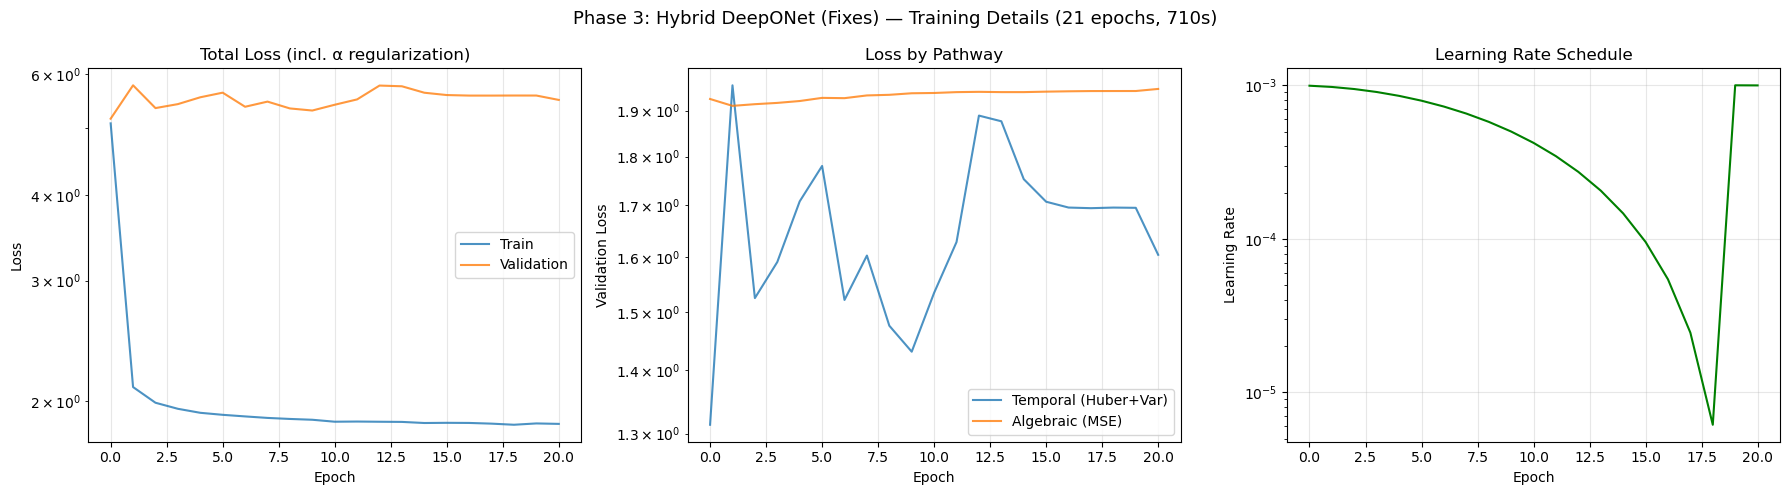

In [ ]:
#  Training Loss Curves

import os
os.makedirs('phase_3_vis', exist_ok=True)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history['train_total'], label='Train', linewidth=1.5, alpha=0.8)
axes[0].plot(history['val_total'], label='Validation', linewidth=1.5, alpha=0.8)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Total Loss (incl. α regularization)')
axes[0].legend()
axes[0].set_yscale('log')
axes[0].grid(True, alpha=0.3)

axes[1].plot(history['val_temporal'], label='Temporal (Huber+Var)', linewidth=1.5, alpha=0.8)
axes[1].plot(history['val_algebraic'], label='Algebraic (MSE)', linewidth=1.5, alpha=0.8)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Validation Loss')
axes[1].set_title('Loss by Pathway')
axes[1].legend()
axes[1].set_yscale('log')
axes[1].grid(True, alpha=0.3)

axes[2].plot(history['lr'], linewidth=1.5, color='green')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Learning Rate')
axes[2].set_title('Learning Rate Schedule')
axes[2].set_yscale('log')
axes[2].grid(True, alpha=0.3)

plt.suptitle(f'Phase 3: Hybrid DeepONet (Fixes) — Training Details ({n_epochs_trained} epochs, {train_time:.0f}s)',
             fontsize=13)
plt.tight_layout()
plt.savefig('phase_3_vis/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## Evaluation on Test Set

### Performance Metrics (from Chapter 3)

**Primary Accuracy Measures:** MAE, RMSE, R², Variance Ratio, Correlation Coefficient

**Delta Prediction Metrics:** Delta Std Ratio, Cumulative Drift Error

**Comparison Metrics:** Persistence R², Skill Score, Beats Persistence flag

**Phase 3–specific:** Skip connection weight (α) analysis

**Computational Performance:** Training time, epochs, model parameters, inference time

In [ ]:
#  Collect Test Predictions

print("Collecting test predictions...")
inference_start = time.time()
test_criterion = HybridLoss(
    temporal_weight=1.0, algebraic_weight=2.0,
    huber_delta=0.5, var_weight=0.1,
    alpha_reg_weight=config.ALPHA_REG_WEIGHT,
)
_, raw_predictions = validate(model, test_loader, test_criterion, DEVICE)
inference_time = time.time() - inference_start

# Convert temporal deltas to absolute
temporal_cols = column_info['temporal_cols']
algebraic_cols = column_info['algebraic_cols']
output_cols = column_info['output_cols']

delta_norm = normalizers['delta']
out_norm = normalizers['output']

temporal_pred_abs = np.zeros_like(raw_predictions['pred_temporal'])
temporal_target_abs = np.zeros_like(raw_predictions['target_temporal'])
for i, col in enumerate(temporal_cols):
    scale = delta_norm.get_scale(col)
    temporal_pred_abs[:, :, i] = raw_predictions['last_temporal'][:, i:i+1] + \
        np.cumsum(raw_predictions['pred_temporal'][:, :, i] * scale, axis=1)
    temporal_target_abs[:, :, i] = raw_predictions['last_temporal'][:, i:i+1] + \
        np.cumsum(raw_predictions['target_temporal'][:, :, i] * scale, axis=1)

# Convert algebraic to absolute
algebraic_pred_abs = np.zeros_like(raw_predictions['pred_algebraic'])
algebraic_target_abs = np.zeros_like(raw_predictions['target_algebraic'])
for step in range(raw_predictions['pred_algebraic'].shape[1]):
    for i, col in enumerate(algebraic_cols):
        s = out_norm.stats[col]
        algebraic_pred_abs[:, step, i] = \
            raw_predictions['pred_algebraic'][:, step, i] * s['std'] + s['mean']
        algebraic_target_abs[:, step, i] = \
            raw_predictions['target_algebraic'][:, step, i] * s['std'] + s['mean']

# Reconstruct combined predictions in original output order
N = temporal_pred_abs.shape[0]
K = config.PREDICTION_STEPS
n_out = len(output_cols)
pred_combined = np.zeros((N, K, n_out), dtype=np.float32)
target_combined = np.zeros((N, K, n_out), dtype=np.float32)

temporal_indices = [output_cols.index(c) for c in temporal_cols]
algebraic_indices = [output_cols.index(c) for c in algebraic_cols]

for i, idx in enumerate(temporal_indices):
    pred_combined[:, :, idx] = temporal_pred_abs[:, :, i]
    target_combined[:, :, idx] = temporal_target_abs[:, :, i]
for i, idx in enumerate(algebraic_indices):
    pred_combined[:, :, idx] = algebraic_pred_abs[:, :, i]
    target_combined[:, :, idx] = algebraic_target_abs[:, :, i]

predictions_dict = {
    'pred_absolute': pred_combined,
    'target_absolute': target_combined,
    'last_output': raw_predictions['last_full'],
    'pred_temporal_norm': raw_predictions['pred_temporal'],
    'target_temporal_norm': raw_predictions['target_temporal'],
    'temporal_pred_abs': temporal_pred_abs,
    'temporal_target_abs': temporal_target_abs,
    'algebraic_pred_abs': algebraic_pred_abs,
    'algebraic_target_abs': algebraic_target_abs,
    'alpha': raw_predictions['alpha'],
}

n_test_samples = pred_combined.shape[0]
print(f"Predictions shape: {pred_combined.shape}")
print(f"Inference time: {inference_time:.2f}s ({inference_time/n_test_samples*1000:.2f} ms/sample)")
print(f"Alpha shape: {raw_predictions['alpha'].shape}")

Predictions shape: (139, 1, 2827)
Inference time: 3.19s (22.95 ms/sample)
Alpha shape: (1, 2313)


In [ ]:
#  Compute Comprehensive Metrics

def compute_metrics(predictions_dict, column_info, config):
    """Compute per-output metrics matching Chapter 3 evaluation criteria."""
    pred = predictions_dict['pred_absolute']
    target = predictions_dict['target_absolute']
    last_out = predictions_dict['last_output']
    output_cols = column_info['output_cols']
    K = config.PREDICTION_STEPS

    results = []
    for i, col in enumerate(output_cols):
        p = pred[:, :, i].flatten()
        t = target[:, :, i].flatten()

        mae = np.mean(np.abs(p - t))
        rmse = np.sqrt(np.mean((p - t) ** 2))

        ss_res = np.sum((t - p) ** 2)
        ss_tot = np.sum((t - t.mean()) ** 2)
        r2 = 1 - ss_res / (ss_tot + 1e-10)

        var_pred = np.var(p)
        var_true = np.var(t)
        variance_ratio = var_pred / (var_true + 1e-10)

        if np.std(p) > 1e-10 and np.std(t) > 1e-10:
            correlation = np.corrcoef(p, t)[0, 1]
        else:
            correlation = 0.0

        # Persistence baseline
        last_val = last_out[:, i]
        persistence = np.repeat(last_val[:, np.newaxis], K, axis=1).flatten()
        ss_res_pers = np.sum((t - persistence) ** 2)
        r2_pers = 1 - ss_res_pers / (ss_tot + 1e-10)
        skill_score = (r2 - r2_pers) / (1 - r2_pers + 1e-10)

        # Delta metrics (for temporal outputs only)
        output_type = column_info['col_to_type'].get(col, 'Unknown')
        pathway = config.get_output_type(col)

        delta_std_ratio = np.nan
        cumulative_drift = 0.0
        if pathway == 'temporal':
            t_idx = column_info['temporal_cols'].index(col) if col in column_info['temporal_cols'] else None
            if t_idx is not None:
                pred_d = predictions_dict['pred_temporal_norm'][:, :, t_idx].flatten()
                targ_d = predictions_dict['target_temporal_norm'][:, :, t_idx].flatten()
                delta_std_ratio = np.std(pred_d) / (np.std(targ_d) + 1e-10)
                if K > 1:
                    t_pred_abs = predictions_dict['temporal_pred_abs']
                    t_targ_abs = predictions_dict['temporal_target_abs']
                    cumulative_drift = np.mean(np.abs(
                        t_pred_abs[:, -1, t_idx] - t_targ_abs[:, -1, t_idx])) - \
                        np.mean(np.abs(
                        t_pred_abs[:, 0, t_idx] - t_targ_abs[:, 0, t_idx]))

        # Per-step R²
        step_r2 = []
        for k in range(K):
            pk = pred[:, k, i]
            tk = target[:, k, i]
            ss_res_k = np.sum((tk - pk) ** 2)
            ss_tot_k = np.sum((tk - tk.mean()) ** 2)
            step_r2.append(1 - ss_res_k / (ss_tot_k + 1e-10))

        cdu_id = column_info['col_to_cdu'].get(col, 'Unknown')
        category = config.get_category(output_type)

        results.append({
            'Output': col,
            'CDU': cdu_id,
            'Type': output_type,
            'Category': category,
            'Pathway': pathway,
            'MAE': mae,
            'RMSE': rmse,
            'R²': r2,
            'Variance_Ratio': variance_ratio,
            'Correlation': correlation,
            'Delta_Std_Ratio': delta_std_ratio,
            'Cumulative_Drift': cumulative_drift,
            'Persistence_R²': r2_pers,
            'Beats_Persistence': r2 > r2_pers,
            'Skill_Score': skill_score,
            **{f'R²_step{k+1}': step_r2[k] for k in range(K)},
        })

    return pd.DataFrame(results)


metrics_df = compute_metrics(predictions_dict, column_info, config)
print(f"Metrics computed for {len(metrics_df)} outputs.")

Metrics computed for 2827 outputs.


In [ ]:
#  Results Summary — Overall, Per-Category, Per-Pathway

print("\n" + "=" * 70)
print("RESULTS SUMMARY — Phase 3: Hybrid DeepONet with Fixes")
print("=" * 70)

# Overall
print(f"\n--- All {len(metrics_df)} Outputs ---")
print(f"  Mean R²:           {metrics_df['R²'].mean():.4f}")
print(f"  Median R²:         {metrics_df['R²'].median():.4f}")
print(f"  Min R²:            {metrics_df['R²'].min():.4f}")
print(f"  Max R²:            {metrics_df['R²'].max():.4f}")
print(f"  Std R²:            {metrics_df['R²'].std():.4f}")
print(f"  Beats Persistence: {metrics_df['Beats_Persistence'].sum()}/{len(metrics_df)} "
      f"({metrics_df['Beats_Persistence'].mean():.1%})")
print(f"  Mean Skill Score:  {metrics_df['Skill_Score'].mean():.4f}")

# Per pathway
print(f"\n--- Per Pathway ---")
for pathway in ['temporal', 'algebraic']:
    pw_df = metrics_df[metrics_df['Pathway'] == pathway]
    print(f"\n  {pathway.upper()} ({len(pw_df)} outputs):")
    print(f"    Mean R²:         {pw_df['R²'].mean():.4f}")
    print(f"    Median R²:       {pw_df['R²'].median():.4f}")
    print(f"    Variance Ratio:  {pw_df['Variance_Ratio'].mean():.4f}")
    print(f"    Beats Persist:   {pw_df['Beats_Persistence'].sum()}/{len(pw_df)}")

# Per-category summary
print(f"\n--- Per-Category Performance ---")
cat_summary = metrics_df.groupby('Category').agg({
    'R²': ['mean', 'median', 'min', 'max', 'count'],
    'RMSE': 'mean',
    'Variance_Ratio': 'mean',
    'Beats_Persistence': 'mean',
}).round(4)
print(cat_summary.to_string())

# Per output-type summary
print(f"\n--- Per Output Type ---")
type_summary = metrics_df.groupby('Type').agg({
    'R²': ['mean', 'median', 'min', 'max'],
    'RMSE': 'mean',
    'MAE': 'mean',
    'Variance_Ratio': 'mean',
    'Correlation': 'mean',
    'Beats_Persistence': 'mean',
}).round(4)
print(type_summary.to_string())

# R² distribution
print(f"\n--- R² Distribution ---")
for threshold, label in [(0.99, '≥ 0.99'), (0.95, '≥ 0.95'), (0.90, '≥ 0.90'),
                          (0.80, '≥ 0.80'), (0.50, '≥ 0.50'), (0.0, '≥ 0.00')]:
    count = (metrics_df['R²'] >= threshold).sum()
    print(f"  R² {label}: {count}/{len(metrics_df)} ({count/len(metrics_df):.1%})")
count_neg = (metrics_df['R²'] < 0).sum()
print(f"  R² < 0.00: {count_neg}/{len(metrics_df)} ({count_neg/len(metrics_df):.1%})")

# Computational summary
print(f"\n--- Computational Performance ---")
print(f"  Model Parameters:     {total_params:,}")
print(f"    Temporal:           {temporal_params:,}")
print(f"    Algebraic:          {algebraic_params:,}")
print(f"  Training Epochs:      {n_epochs_trained}")
print(f"  Training Time:        {train_time:.1f}s ({train_time/60:.1f} min)")
print(f"  Inference Time:       {inference_time:.2f}s")
print(f"  Per sample:           {inference_time/n_test_samples*1000:.2f} ms")


RESULTS SUMMARY — Phase 3: Hybrid DeepONet with Fixes

--- All 2827 Outputs ---
  Mean R²:           -0.4956
  Median R²:         0.9953
  Min R²:            -36.0896
  Max R²:            1.0000
  Std R²:            3.6130
  Beats Persistence: 263/2827 (9.3%)
  Mean Skill Score:  -8.4496

--- Per Pathway ---

  TEMPORAL (2313 outputs):
    Mean R²:         -0.0409
    Median R²:       0.9953
    Variance Ratio:  1.0006
    Beats Persist:   261/2313

  ALGEBRAIC (514 outputs):
    Mean R²:         -2.5419
    Median R²:       -0.9838
    Variance Ratio:  0.0660
    Beats Persist:   2/514

--- Per-Category Performance ---
                            R²                                   RMSE Variance_Ratio Beats_Persistence
                          mean  median      min     max count    mean           mean              mean
Category                                                                                              
A (Primary loop)        0.9939  0.9954   0.8064  1.0000  1028 

## Evaluation Metric Visualizations

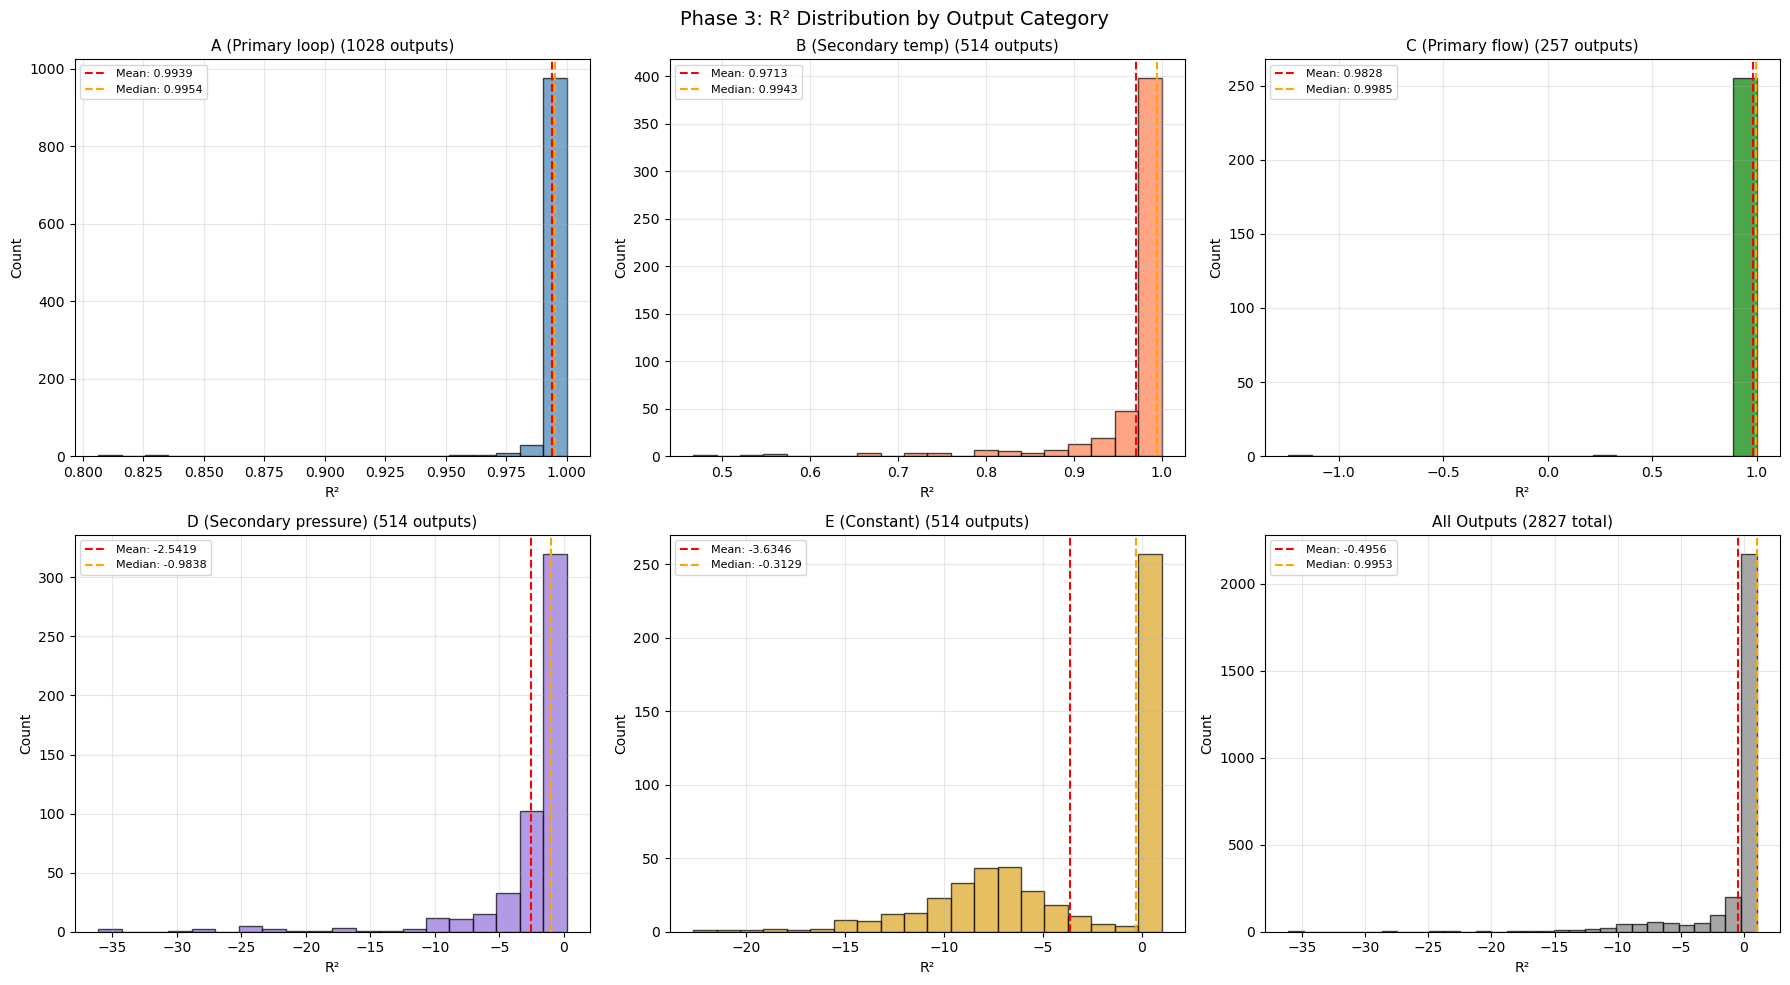

In [ ]:
#  Visualization 1 — R² Distribution by Category

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

categories = ['A (Primary loop)', 'B (Secondary temp)', 'C (Primary flow)',
              'D (Secondary pressure)', 'E (Constant)']
colors = ['steelblue', 'coral', 'green', 'mediumpurple', 'goldenrod']

for idx, (cat, color) in enumerate(zip(categories, colors)):
    ax = axes[idx]
    cat_data = metrics_df[metrics_df['Category'] == cat]['R²']
    if len(cat_data) == 0:
        ax.set_visible(False)
        continue
    ax.hist(cat_data, bins=min(20, len(cat_data)), alpha=0.7,
            edgecolor='black', color=color)
    ax.axvline(cat_data.mean(), color='red', linestyle='--', linewidth=1.5,
               label=f'Mean: {cat_data.mean():.4f}')
    ax.axvline(cat_data.median(), color='orange', linestyle='--', linewidth=1.5,
               label=f'Median: {cat_data.median():.4f}')
    ax.set_title(f'{cat} ({len(cat_data)} outputs)', fontsize=11)
    ax.set_xlabel('R²')
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

ax = axes[5]
ax.hist(metrics_df['R²'], bins=30, alpha=0.7, edgecolor='black', color='gray')
ax.axvline(metrics_df['R²'].mean(), color='red', linestyle='--', linewidth=1.5,
           label=f'Mean: {metrics_df["R²"].mean():.4f}')
ax.axvline(metrics_df['R²'].median(), color='orange', linestyle='--', linewidth=1.5,
           label=f'Median: {metrics_df["R²"].median():.4f}')
ax.set_title(f'All Outputs ({len(metrics_df)} total)', fontsize=11)
ax.set_xlabel('R²')
ax.set_ylabel('Count')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.suptitle('Phase 3: R² Distribution by Output Category', fontsize=14)
plt.tight_layout()
plt.savefig('phase_3_vis/r2_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

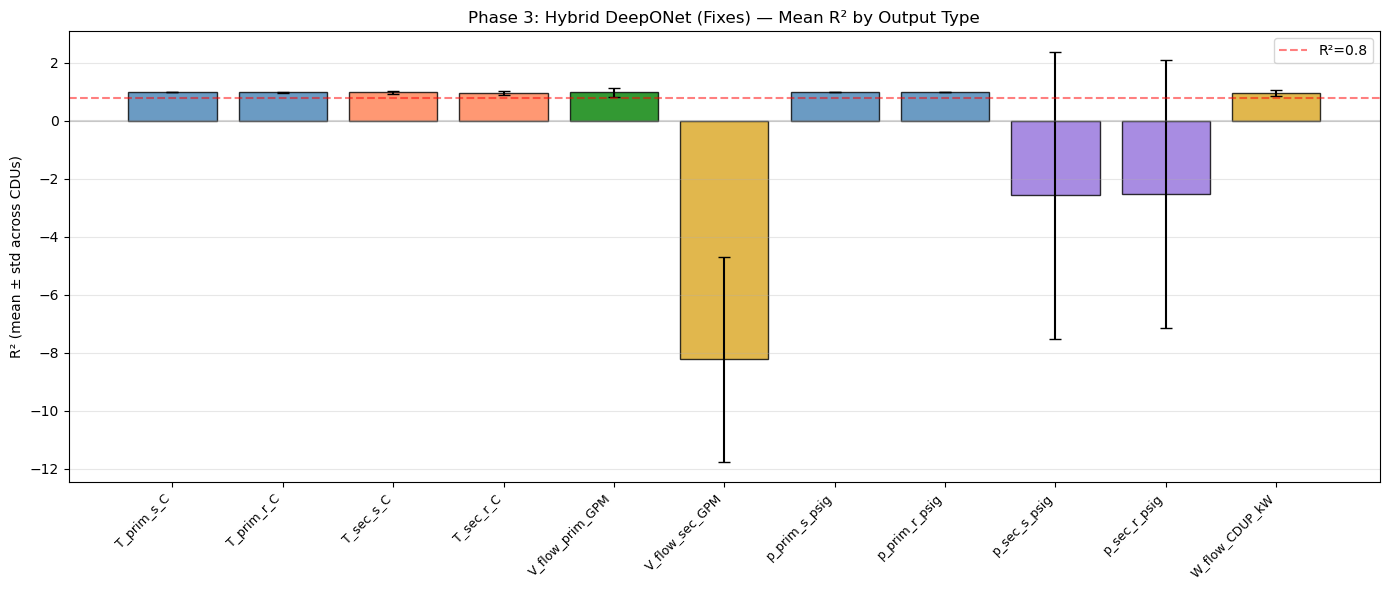

In [ ]:
#  Visualization 2 — Per-Output-Type R² Bar Chart

output_types = config.OUTPUT_NAMES
type_means = metrics_df.groupby('Type')['R²'].agg(['mean', 'std']).reindex(output_types)

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(output_types))
bars = ax.bar(x, type_means['mean'], yerr=type_means['std'], capsize=4,
              color='steelblue', alpha=0.8, edgecolor='black')

color_map = {
    'A (Primary loop)': 'steelblue', 'B (Secondary temp)': 'coral',
    'C (Primary flow)': 'green', 'D (Secondary pressure)': 'mediumpurple',
    'E (Constant)': 'goldenrod',
}
for i, otype in enumerate(output_types):
    cat = config.get_category(otype)
    bars[i].set_facecolor(color_map.get(cat, 'gray'))

ax.set_xticks(x)
ax.set_xticklabels(output_types, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('R² (mean ± std across CDUs)')
ax.set_title('Phase 3: Hybrid DeepONet (Fixes) — Mean R² by Output Type')
ax.axhline(y=0.8, color='red', linestyle='--', alpha=0.5, label='R²=0.8')
ax.axhline(y=0.0, color='gray', linestyle='-', alpha=0.3)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('phase_3_vis/r2_by_type.png', dpi=150, bbox_inches='tight')
plt.show()

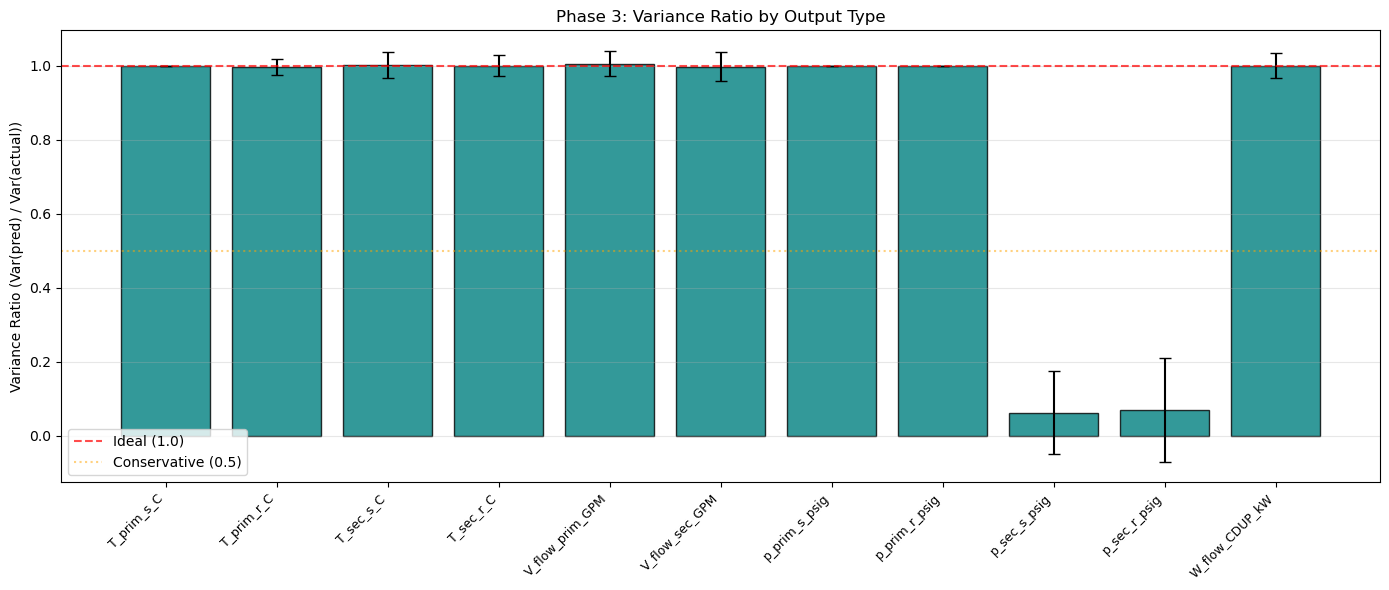

In [ ]:
#  Visualization 3 — Variance Ratio by Output Type

fig, ax = plt.subplots(figsize=(14, 6))
type_var = metrics_df.groupby('Type')['Variance_Ratio'].agg(['mean', 'std']).reindex(output_types)

x = np.arange(len(output_types))
bars = ax.bar(x, type_var['mean'], yerr=type_var['std'], capsize=4,
              color='teal', alpha=0.8, edgecolor='black')

ax.set_xticks(x)
ax.set_xticklabels(output_types, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Variance Ratio (Var(pred) / Var(actual))')
ax.set_title('Phase 3: Variance Ratio by Output Type')
ax.axhline(y=1.0, color='red', linestyle='--', alpha=0.7, label='Ideal (1.0)')
ax.axhline(y=0.5, color='orange', linestyle=':', alpha=0.5, label='Conservative (0.5)')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('phase_3_vis/variance_ratio.png', dpi=150, bbox_inches='tight')
plt.show()

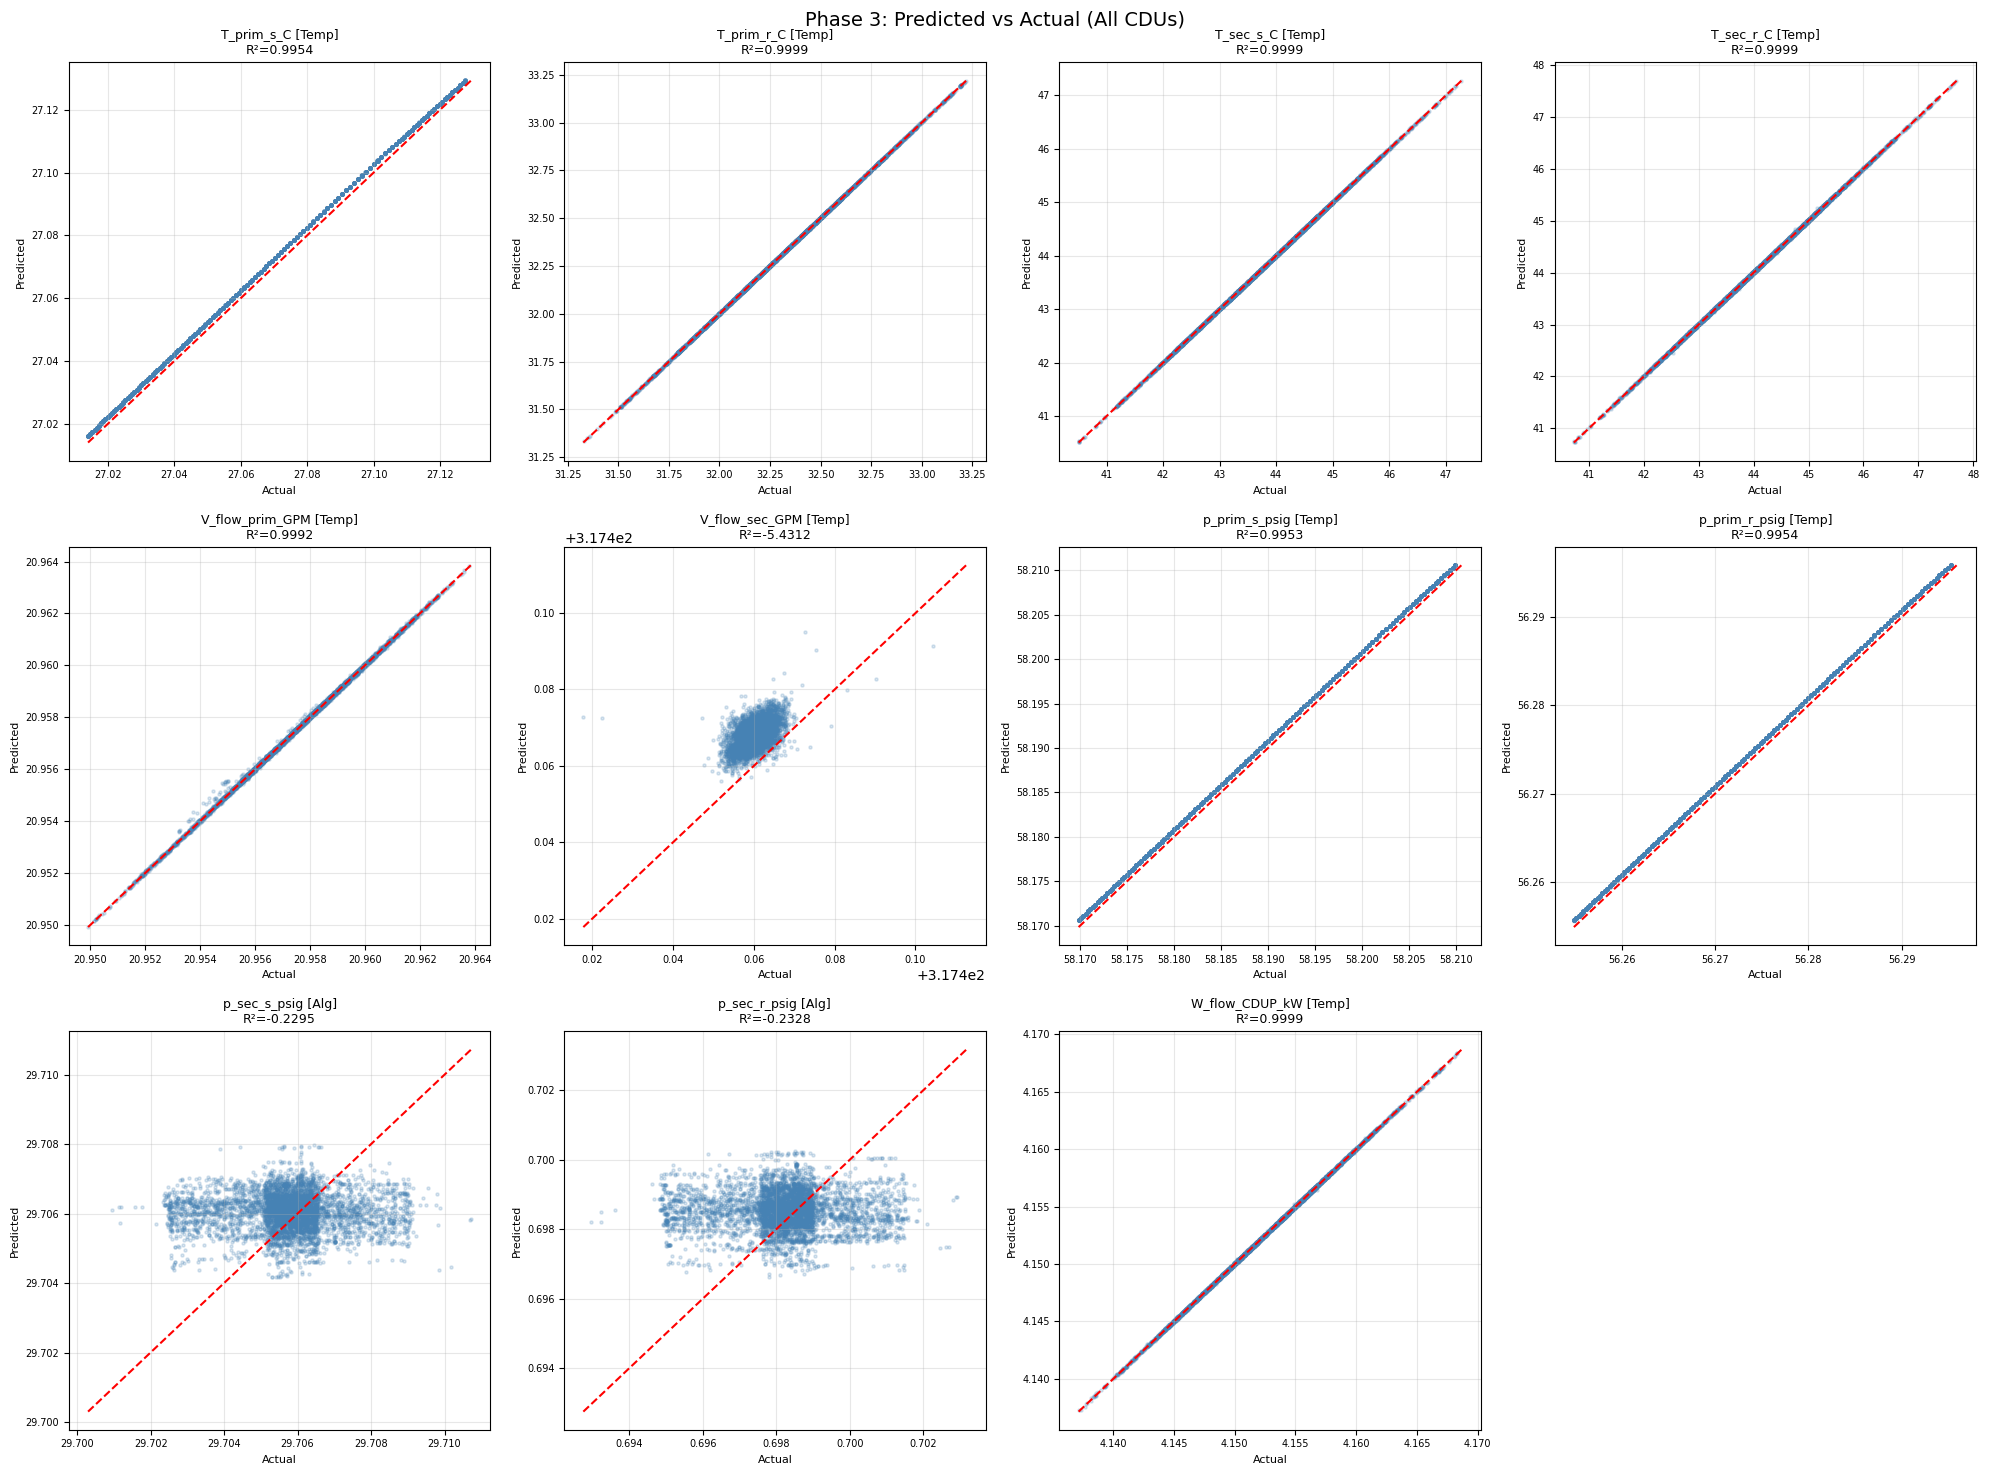

In [ ]:
#  Visualization 4 — Scatter Plots per Output Type

pred = predictions_dict['pred_absolute']
target = predictions_dict['target_absolute']

fig, axes = plt.subplots(3, 4, figsize=(20, 15))
axes = axes.flatten()

for idx, output_type in enumerate(config.OUTPUT_NAMES):
    if idx >= len(axes):
        break
    ax = axes[idx]

    all_pred, all_target = [], []
    for col_idx, col in enumerate(output_cols):
        if column_info['col_to_type'].get(col) == output_type:
            all_pred.append(pred[:, :, col_idx].flatten())
            all_target.append(target[:, :, col_idx].flatten())

    if len(all_pred) == 0:
        ax.set_visible(False)
        continue

    all_pred_arr = np.concatenate(all_pred)
    all_target_arr = np.concatenate(all_target)

    n_plot = min(5000, len(all_pred_arr))
    plot_idx = np.random.choice(len(all_pred_arr), n_plot, replace=False)

    ax.scatter(all_target_arr[plot_idx], all_pred_arr[plot_idx], alpha=0.2, s=5, c='steelblue')
    vmin = min(all_target_arr.min(), all_pred_arr.min())
    vmax = max(all_target_arr.max(), all_pred_arr.max())
    ax.plot([vmin, vmax], [vmin, vmax], 'r--', linewidth=1.5)

    ss_res = np.sum((all_target_arr - all_pred_arr) ** 2)
    ss_tot = np.sum((all_target_arr - all_target_arr.mean()) ** 2)
    r2 = 1 - ss_res / (ss_tot + 1e-10)

    pathway = 'Alg' if output_type in config.ALGEBRAIC_OUTPUTS else 'Temp'
    ax.set_title(f'{output_type} [{pathway}]\nR²={r2:.4f}', fontsize=9)
    ax.set_xlabel('Actual', fontsize=8)
    ax.set_ylabel('Predicted', fontsize=8)
    ax.tick_params(labelsize=7)
    ax.grid(True, alpha=0.3)

for idx in range(len(config.OUTPUT_NAMES), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Phase 3: Predicted vs Actual (All CDUs)', fontsize=14)
plt.tight_layout()
plt.savefig('phase_3_vis/scatter_plots.png', dpi=150, bbox_inches='tight')
plt.show()

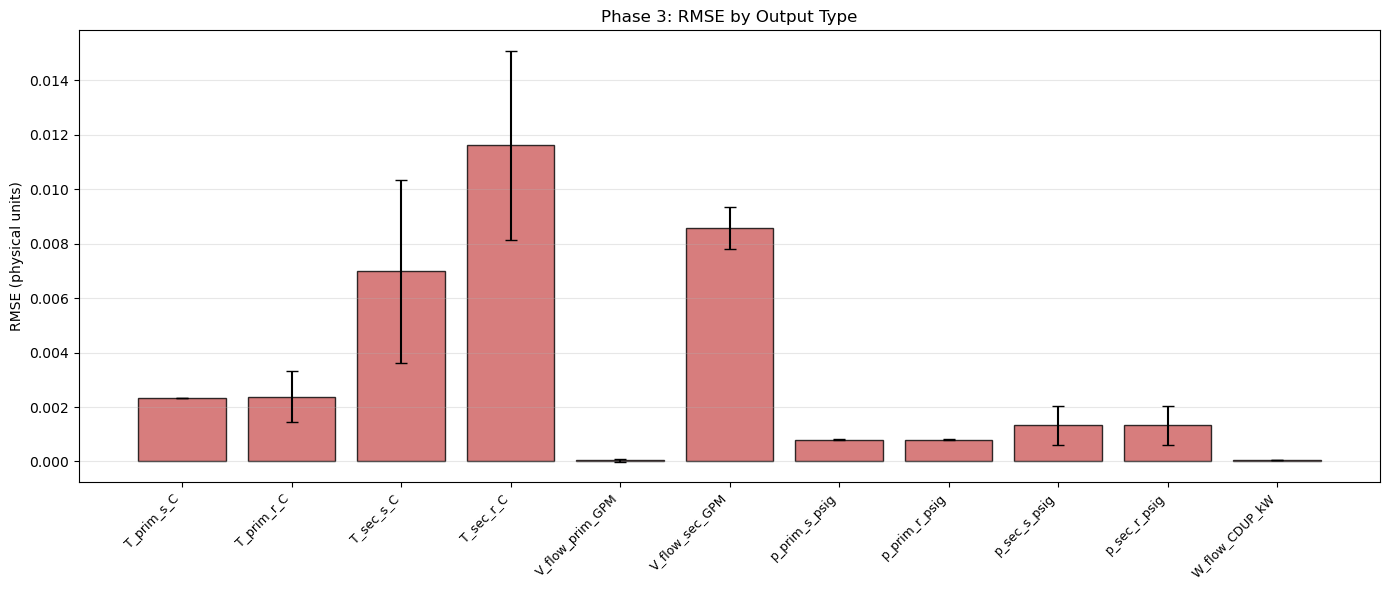

In [ ]:
#  Visualization 5 — RMSE by Output Type

fig, ax = plt.subplots(figsize=(14, 6))
type_rmse = metrics_df.groupby('Type')['RMSE'].agg(['mean', 'std']).reindex(output_types)

x = np.arange(len(output_types))
bars = ax.bar(x, type_rmse['mean'], yerr=type_rmse['std'], capsize=4,
              color='indianred', alpha=0.8, edgecolor='black')

ax.set_xticks(x)
ax.set_xticklabels(output_types, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('RMSE (physical units)')
ax.set_title('Phase 3: RMSE by Output Type')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('phase_3_vis/rmse_by_type.png', dpi=150, bbox_inches='tight')
plt.show()

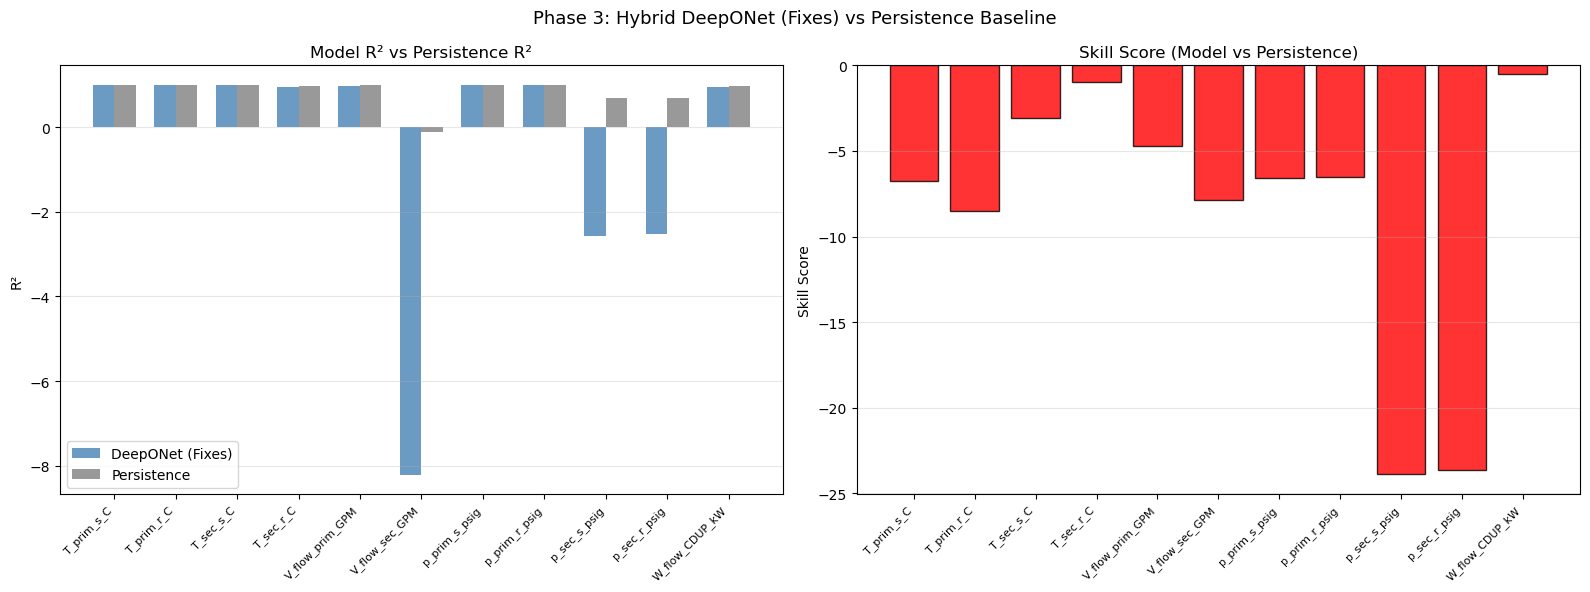

In [ ]:
#  Visualization 6 — Model vs Persistence Comparison

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

model_r2 = metrics_df.groupby('Type')['R²'].mean().reindex(output_types)
persist_r2 = metrics_df.groupby('Type')['Persistence_R²'].mean().reindex(output_types)

x = np.arange(len(output_types))
width = 0.35
axes[0].bar(x - width/2, model_r2, width, label='DeepONet (Fixes)', color='steelblue', alpha=0.8)
axes[0].bar(x + width/2, persist_r2, width, label='Persistence', color='gray', alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(output_types, rotation=45, ha='right', fontsize=8)
axes[0].set_ylabel('R²')
axes[0].set_title('Model R² vs Persistence R²')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

skill = metrics_df.groupby('Type')['Skill_Score'].mean().reindex(output_types)
colors_skill = ['green' if s > 0 else 'red' for s in skill]
axes[1].bar(x, skill, color=colors_skill, alpha=0.8, edgecolor='black')
axes[1].set_xticks(x)
axes[1].set_xticklabels(output_types, rotation=45, ha='right', fontsize=8)
axes[1].set_ylabel('Skill Score')
axes[1].set_title('Skill Score (Model vs Persistence)')
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[1].grid(True, alpha=0.3, axis='y')

plt.suptitle('Phase 3: Hybrid DeepONet (Fixes) vs Persistence Baseline', fontsize=13)
plt.tight_layout()
plt.savefig('phase_3_vis/vs_persistence.png', dpi=150, bbox_inches='tight')
plt.show()

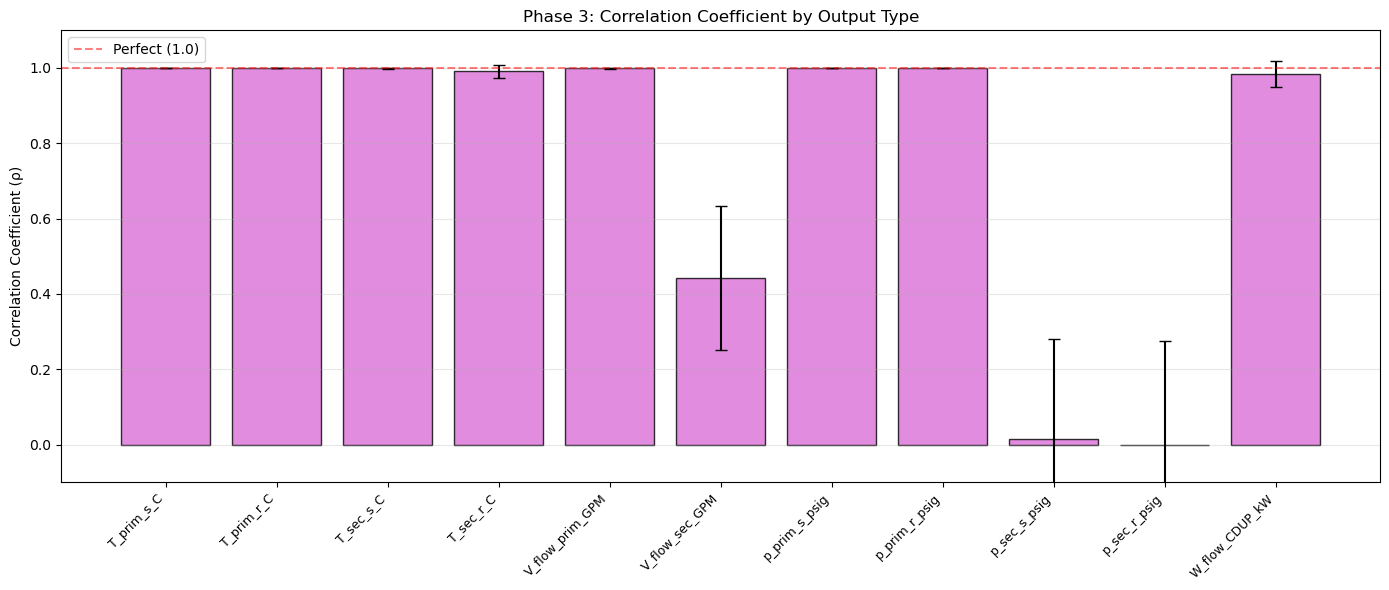

In [ ]:
#  Visualization 7 — Correlation Coefficient by Output Type

fig, ax = plt.subplots(figsize=(14, 6))
type_corr = metrics_df.groupby('Type')['Correlation'].agg(['mean', 'std']).reindex(output_types)

x = np.arange(len(output_types))
bars = ax.bar(x, type_corr['mean'], yerr=type_corr['std'], capsize=4,
              color='orchid', alpha=0.8, edgecolor='black')

ax.set_xticks(x)
ax.set_xticklabels(output_types, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Correlation Coefficient (ρ)')
ax.set_title('Phase 3: Correlation Coefficient by Output Type')
ax.axhline(y=1.0, color='red', linestyle='--', alpha=0.5, label='Perfect (1.0)')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(-0.1, 1.1)
plt.tight_layout()
plt.savefig('phase_3_vis/correlation.png', dpi=150, bbox_inches='tight')
plt.show()

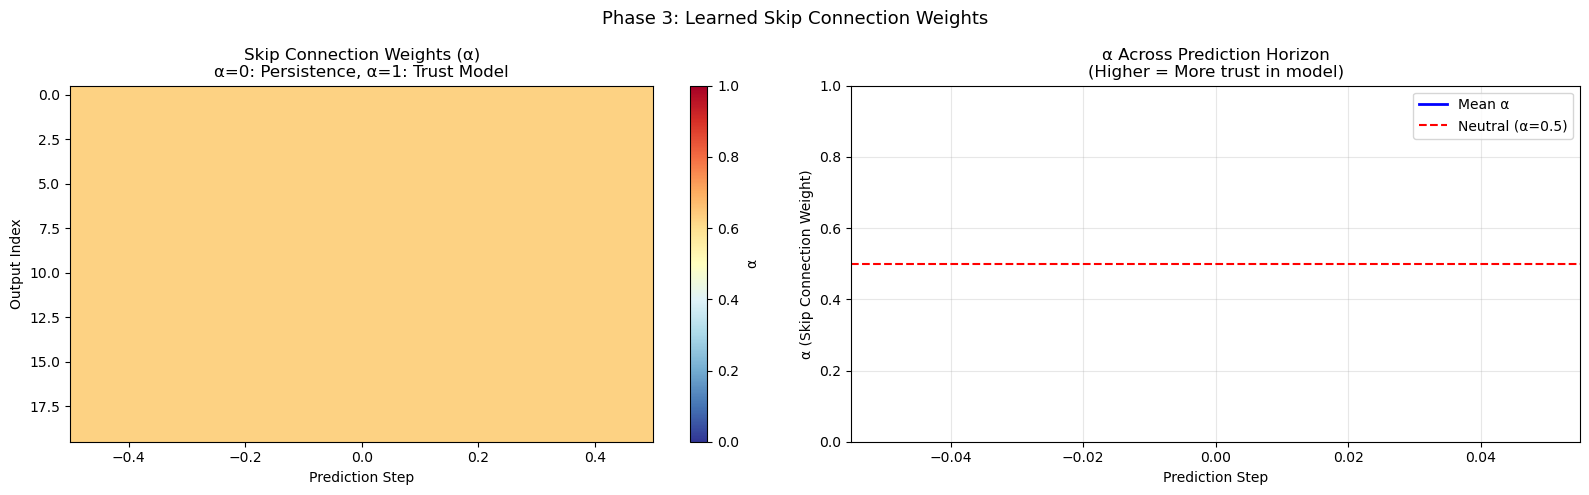


Skip Connection Weight (α) Summary:
  Mean α:         0.625
  Min α:          0.625
  Max α:          0.625
  α at step 0:    0.625 (early predictions)
  α at step -1:   0.625 (late predictions)


In [ ]:
#  Visualization 8 — Skip Connection Weight Analysis (Phase 3–specific)

def plot_alpha_weights(alpha, temporal_cols, config):
    """Visualize the learned skip connection weights (α)."""
    pred_steps = alpha.shape[0]
    n_outputs = min(alpha.shape[1], 20)

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Heatmap
    ax = axes[0]
    im = ax.imshow(alpha[:, :n_outputs].T, aspect='auto', cmap='RdYlBu_r', vmin=0, vmax=1)
    ax.set_xlabel('Prediction Step')
    ax.set_ylabel('Output Index')
    ax.set_title('Skip Connection Weights (α)\nα=0: Persistence, α=1: Trust Model')
    plt.colorbar(im, ax=ax, label='α')

    # Line plot
    ax = axes[1]
    alpha_mean = alpha.mean(axis=1)
    alpha_std = alpha.std(axis=1)
    steps = np.arange(pred_steps)

    ax.fill_between(steps, alpha_mean - alpha_std, alpha_mean + alpha_std, alpha=0.3)
    ax.plot(steps, alpha_mean, 'b-', linewidth=2, label='Mean α')
    ax.axhline(y=0.5, color='r', linestyle='--', label='Neutral (α=0.5)')
    ax.set_xlabel('Prediction Step')
    ax.set_ylabel('α (Skip Connection Weight)')
    ax.set_title('α Across Prediction Horizon\n(Higher = More trust in model)')
    ax.legend()
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)

    plt.suptitle('Phase 3: Learned Skip Connection Weights', fontsize=13)
    plt.tight_layout()
    plt.savefig('phase_3_vis/alpha_weights.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f"\nSkip Connection Weight (α) Summary:")
    print(f"  Mean α:         {alpha.mean():.3f}")
    print(f"  Min α:          {alpha.min():.3f}")
    print(f"  Max α:          {alpha.max():.3f}")
    print(f"  α at step 0:    {alpha[0].mean():.3f} (early predictions)")
    print(f"  α at step -1:   {alpha[-1].mean():.3f} (late predictions)")


plot_alpha_weights(predictions_dict['alpha'], temporal_cols, config)

## Time-Series Predictions (300-second sample)

For each output type and CDU, a 300-second window comparing:
- **Actual** (ground truth) values
- **Model prediction** (DeepONet with fixes)
- **Persistence baseline** (last observed value)

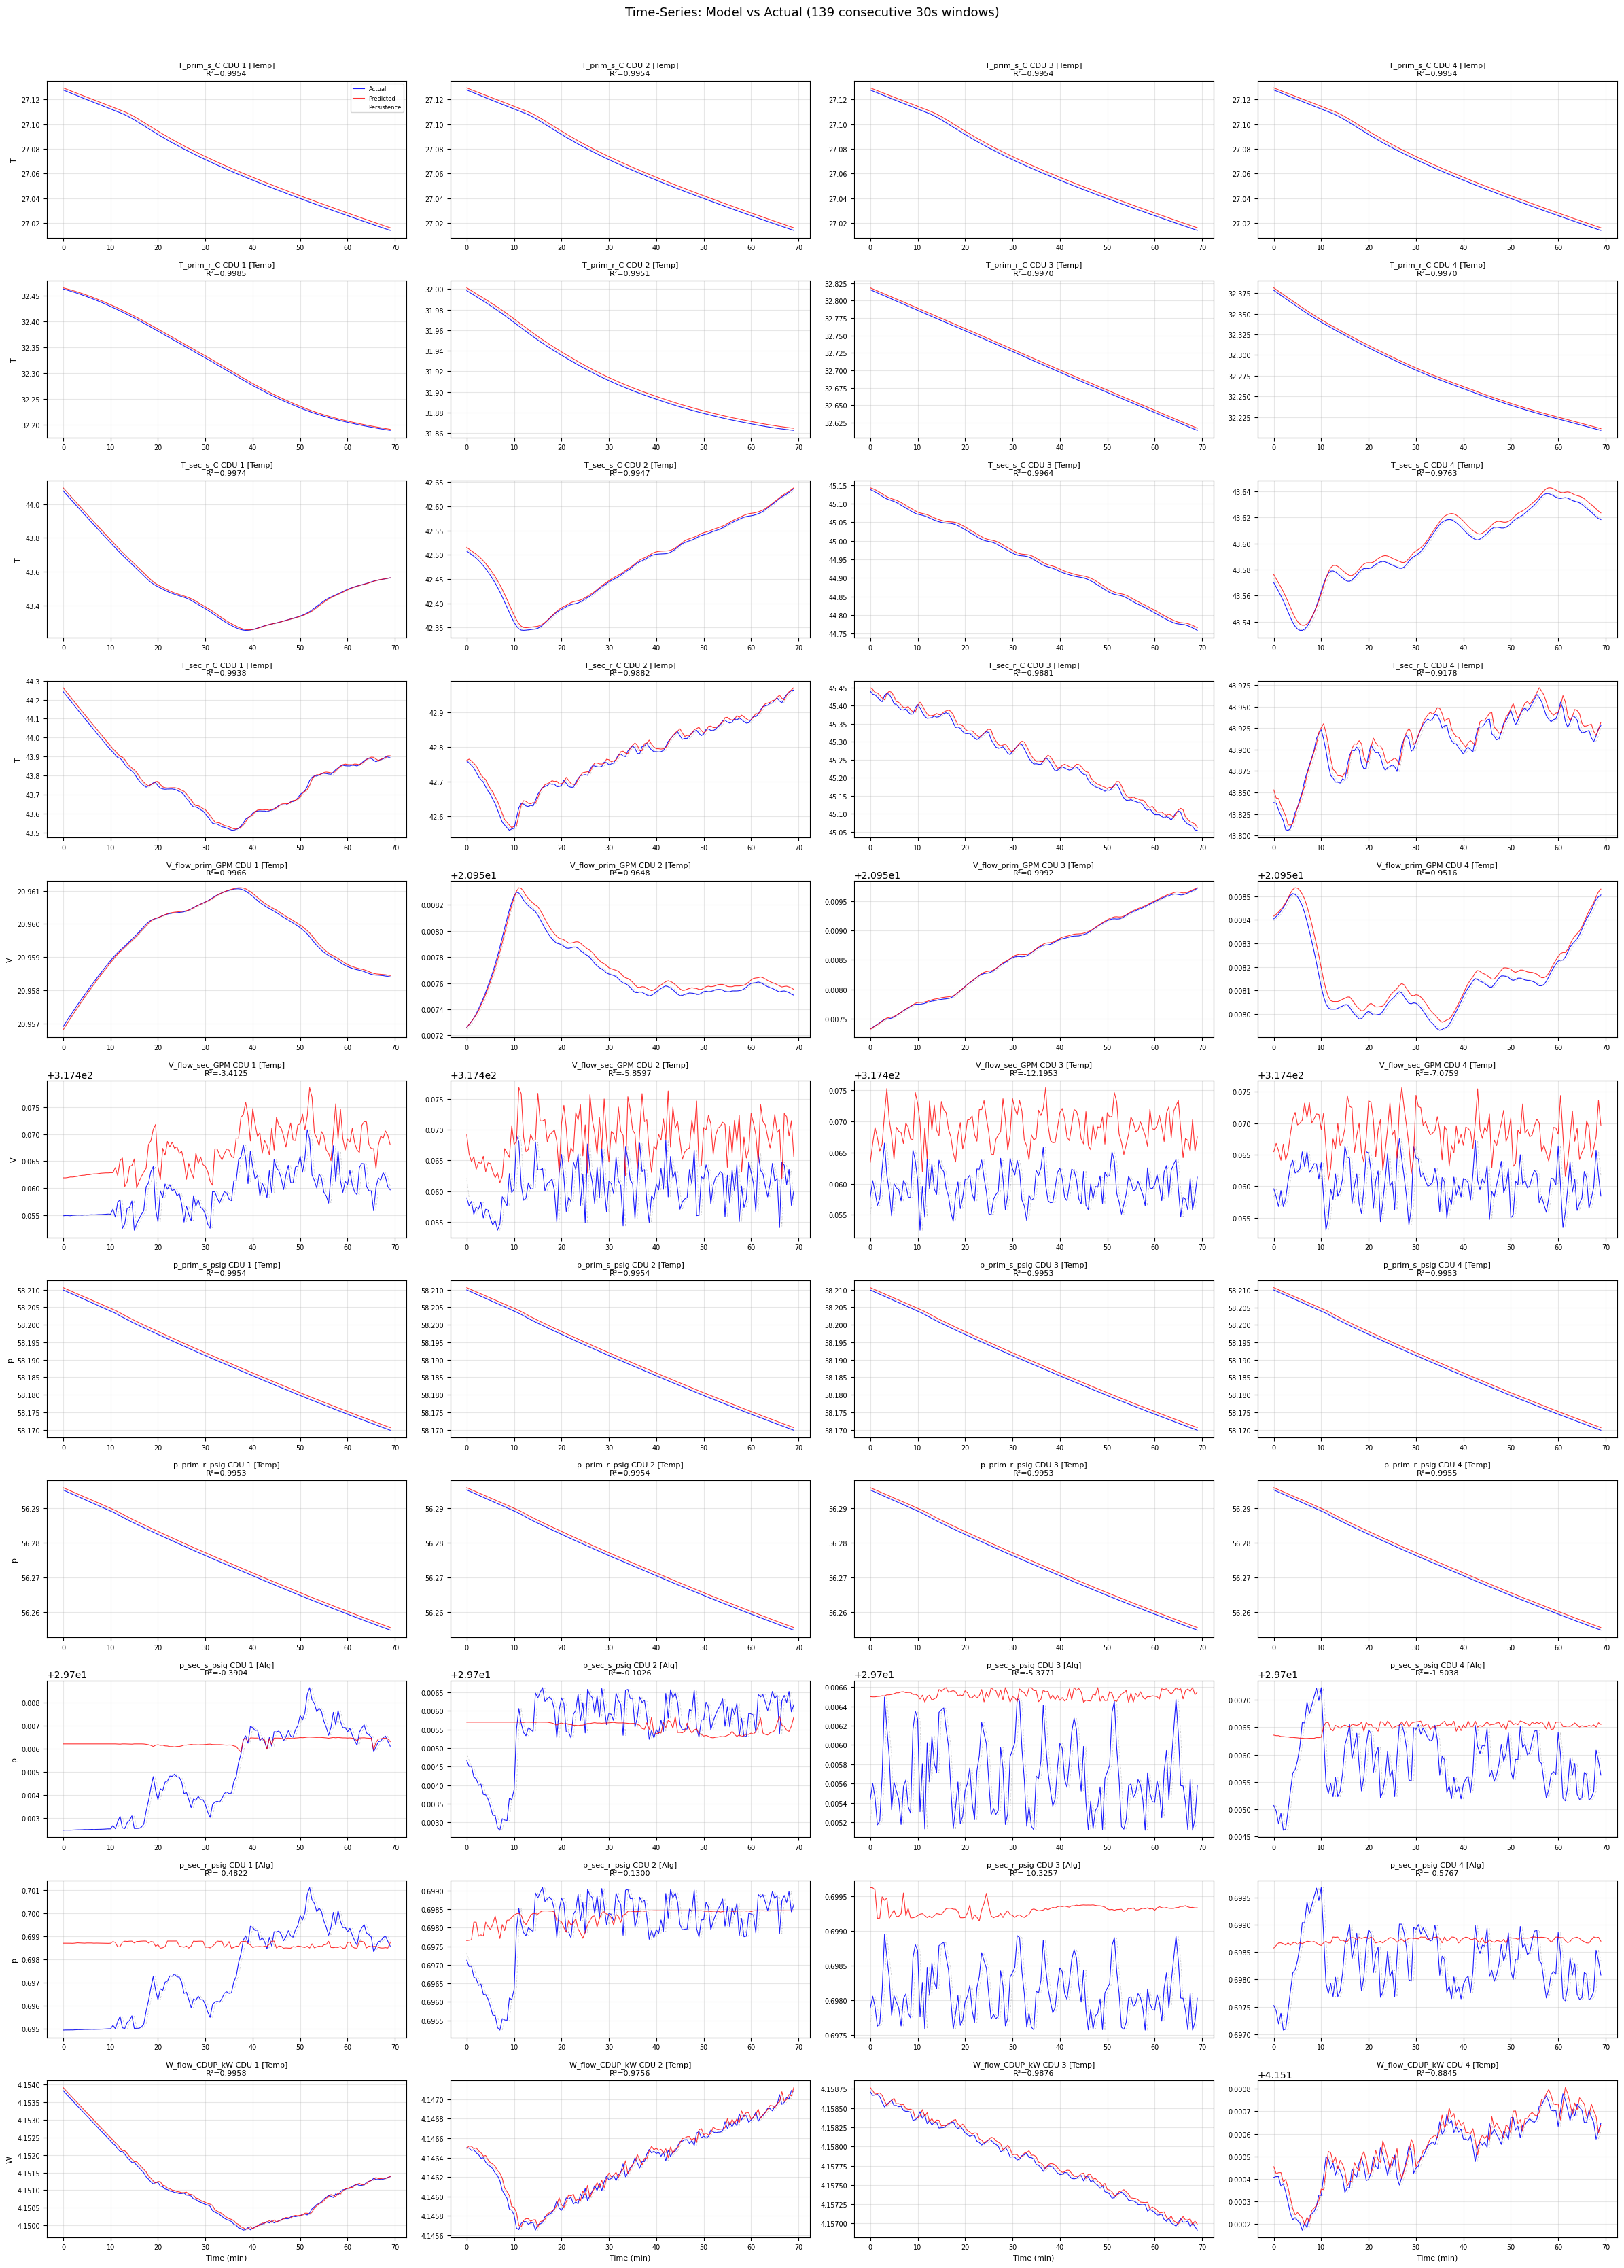

In [ ]:
#  Time-Series Predictions — Chain consecutive prediction windows
# (matching dl_12_federated_DeepM&Mnet.ipynb style)

def plot_timeseries_predictions(predictions_dict, column_info, config,
                                 n_cdus=4, n_samples_show=200):
    """
    Chain consecutive prediction windows into a continuous time-series
    for every output type × selected CDUs.
    """
    pred = predictions_dict['pred_absolute']
    target = predictions_dict['target_absolute']
    last_out = predictions_dict['last_output']
    output_cols = column_info['output_cols']

    K = config.PREDICTION_STEPS
    dt = config.SUBSAMPLE_FACTOR   # seconds per step

    N = min(n_samples_show, pred.shape[0])
    cdu_ids = config.CDU_IDS[:n_cdus]

    output_names = config.OUTPUT_NAMES
    n_types = len(output_names)

    fig, axes = plt.subplots(n_types, n_cdus, figsize=(6 * n_cdus, 3.0 * n_types),
                             squeeze=False)

    for row, output_type in enumerate(output_names):
        for col_idx, cdu_id in enumerate(cdu_ids):
            ax = axes[row, col_idx]

            pattern = config.OUTPUT_PATTERNS[output_type]
            col_name = pattern.format(cdu_id)
            if col_name not in output_cols:
                ax.set_visible(False)
                continue
            idx = output_cols.index(col_name)

            # Build time-series from consecutive prediction windows
            t_vals, y_actual, y_pred, y_persist = [], [], [], []
            for i in range(N):
                for k in range(K):
                    t_sec = (i * K + k) * dt
                    t_vals.append(t_sec)
                    y_actual.append(target[i, k, idx])
                    y_pred.append(pred[i, k, idx])
                    y_persist.append(last_out[i, idx])

            t_min = np.array(t_vals) / 60.0
            y_actual = np.array(y_actual)
            y_pred = np.array(y_pred)
            y_persist = np.array(y_persist)

            ax.plot(t_min, y_actual, 'b-', label='Actual', linewidth=0.8, alpha=0.9)
            ax.plot(t_min, y_pred, 'r-', label='Predicted', linewidth=0.8, alpha=0.8)
            ax.plot(t_min, y_persist, 'gray', linestyle=':', label='Persistence',
                    linewidth=0.6, alpha=0.5)

            # Compute R² for this specific output
            ss_res = np.sum((y_actual - y_pred) ** 2)
            ss_tot = np.sum((y_actual - y_actual.mean()) ** 2)
            r2 = 1 - ss_res / (ss_tot + 1e-10)

            pathway = 'Alg' if output_type in config.ALGEBRAIC_OUTPUTS else 'Temp'
            ax.set_title(f'{output_type} CDU {cdu_id} [{pathway}]\nR²={r2:.4f}', fontsize=8)
            if col_idx == 0:
                ax.set_ylabel(output_type.split('_')[0], fontsize=8)
            if row == n_types - 1:
                ax.set_xlabel('Time (min)', fontsize=8)
            if row == 0 and col_idx == 0:
                ax.legend(fontsize=6, loc='upper right')
            ax.tick_params(labelsize=7)
            ax.grid(True, alpha=0.3)

    plt.suptitle(
        f'Time-Series: Model vs Actual ({N} consecutive {K*dt}s windows)',
        fontsize=13, y=1.01,
    )
    plt.tight_layout()
    plt.savefig('phase_3_vis/timeseries_predictions.png', dpi=150, bbox_inches='tight')
    plt.show()


plot_timeseries_predictions(predictions_dict, column_info, config)

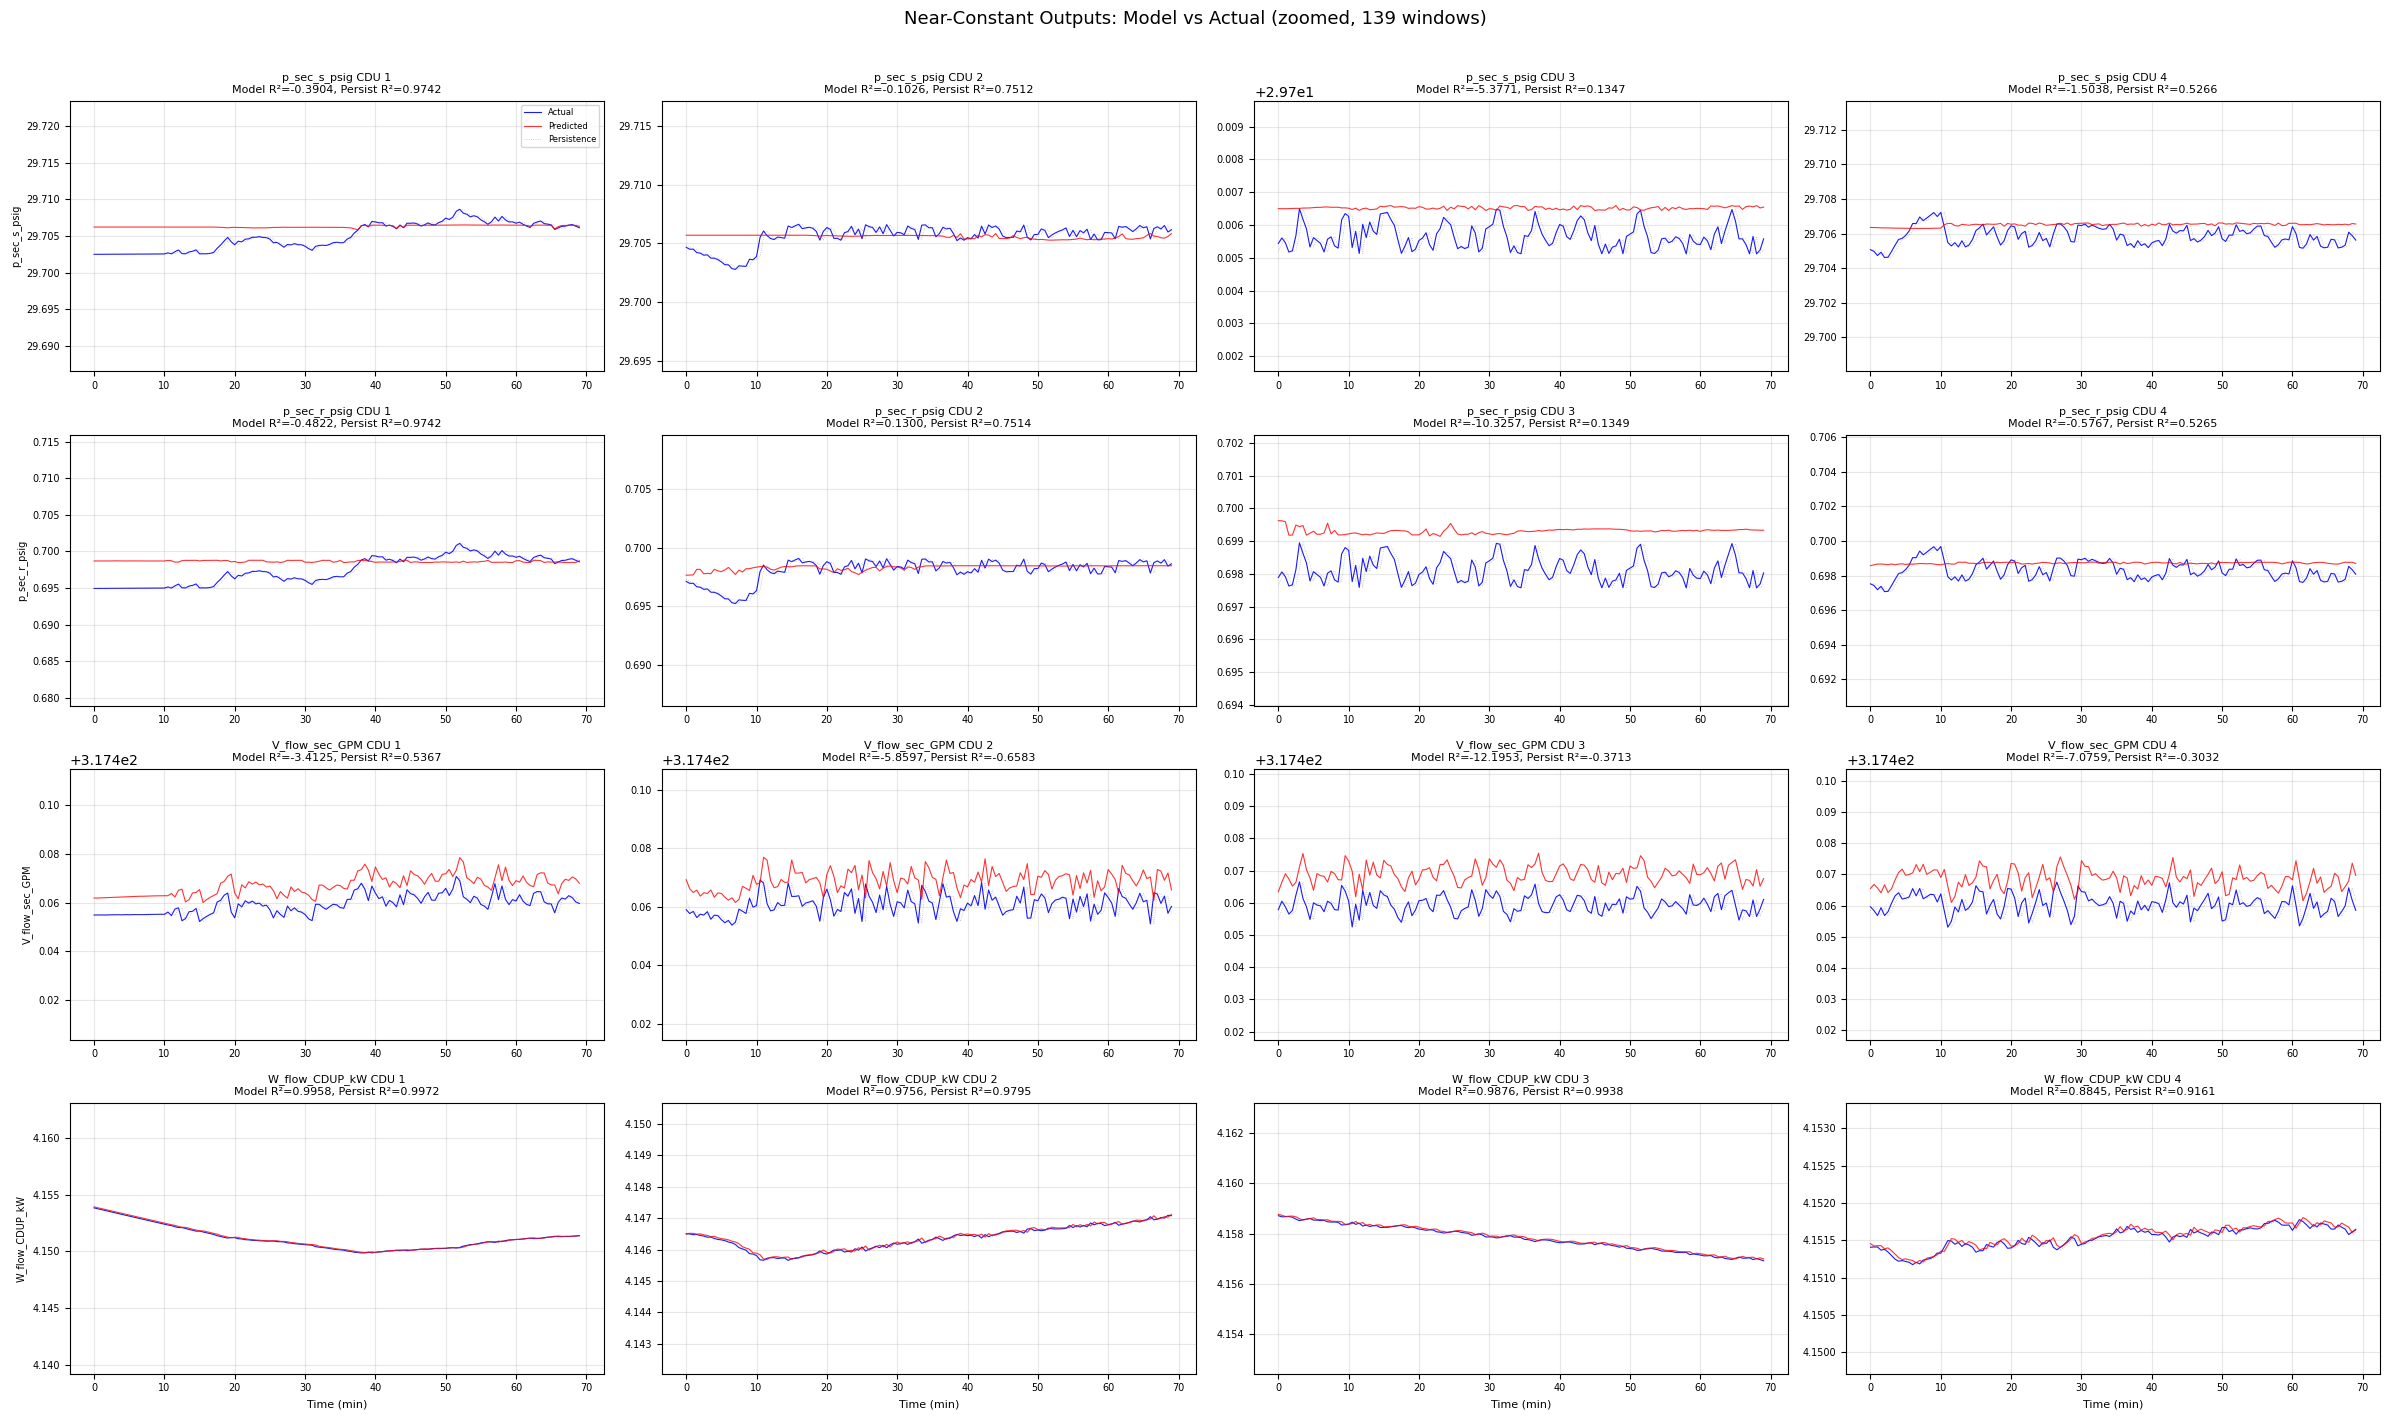

In [ ]:
#  Near-Constant Output Time-Series (Zoomed)
# (matching dl_12_federated_DeepM&Mnet.ipynb style)

def plot_timeseries_nearconst(predictions_dict, column_info, config,
                               n_cdus=4, n_samples_show=200):
    """
    Dedicated time-series for near-constant outputs (Category D, E).
    Y-axis zoomed to ±3× data range for visibility of tiny fluctuations.
    """
    pred = predictions_dict['pred_absolute']
    target = predictions_dict['target_absolute']
    last_out = predictions_dict['last_output']
    output_cols = column_info['output_cols']

    nearconst_types = config.CATEGORY_D + config.CATEGORY_E
    n_types = len(nearconst_types)
    K = config.PREDICTION_STEPS
    dt = config.SUBSAMPLE_FACTOR
    N = min(n_samples_show, pred.shape[0])

    cdu_ids = config.CDU_IDS[:n_cdus]

    fig, axes = plt.subplots(n_types, n_cdus, figsize=(6 * n_cdus, 3.5 * n_types),
                             squeeze=False)

    for row, output_type in enumerate(nearconst_types):
        for col_idx, cdu_id in enumerate(cdu_ids):
            ax = axes[row, col_idx]

            pattern = config.OUTPUT_PATTERNS[output_type]
            col_name = pattern.format(cdu_id)
            if col_name not in output_cols:
                ax.set_visible(False)
                continue
            idx = output_cols.index(col_name)

            t_vals, y_actual, y_pred, y_persist = [], [], [], []
            for i in range(N):
                for k in range(K):
                    t_sec = (i * K + k) * dt
                    t_vals.append(t_sec)
                    y_actual.append(target[i, k, idx])
                    y_pred.append(pred[i, k, idx])
                    y_persist.append(last_out[i, idx])

            t_min = np.array(t_vals) / 60.0
            y_actual = np.array(y_actual)
            y_pred = np.array(y_pred)
            y_persist = np.array(y_persist)

            ax.plot(t_min, y_actual, 'b-', label='Actual', linewidth=0.8, alpha=0.9)
            ax.plot(t_min, y_pred, 'r-', label='Predicted', linewidth=0.8, alpha=0.8)
            ax.plot(t_min, y_persist, 'gray', linestyle=':', label='Persistence',
                    linewidth=0.6, alpha=0.5)

            # Zoom to ±3× range for visibility
            y_mean = y_actual.mean()
            y_range = max(y_actual.max() - y_actual.min(), 1e-4)
            margin = y_range * 3
            ax.set_ylim(y_mean - margin, y_mean + margin)

            ss_res = np.sum((y_actual - y_pred) ** 2)
            ss_tot = np.sum((y_actual - y_actual.mean()) ** 2)
            r2 = 1 - ss_res / (ss_tot + 1e-10)

            ss_res_p = np.sum((y_actual - y_persist) ** 2)
            r2_p = 1 - ss_res_p / (ss_tot + 1e-10)

            ax.set_title(f'{output_type} CDU {cdu_id}\nModel R²={r2:.4f}, '
                         f'Persist R²={r2_p:.4f}', fontsize=8)
            if col_idx == 0:
                ax.set_ylabel(output_type, fontsize=7)
            if row == n_types - 1:
                ax.set_xlabel('Time (min)', fontsize=8)
            if row == 0 and col_idx == 0:
                ax.legend(fontsize=6, loc='upper right')
            ax.tick_params(labelsize=7)
            ax.grid(True, alpha=0.3)

    plt.suptitle(
        f'Near-Constant Outputs: Model vs Actual (zoomed, {N} windows)',
        fontsize=13, y=1.01,
    )
    plt.tight_layout()
    plt.savefig('phase_3_vis/timeseries_nearconst.png', dpi=150, bbox_inches='tight')
    plt.show()


plot_timeseries_nearconst(predictions_dict, column_info, config)

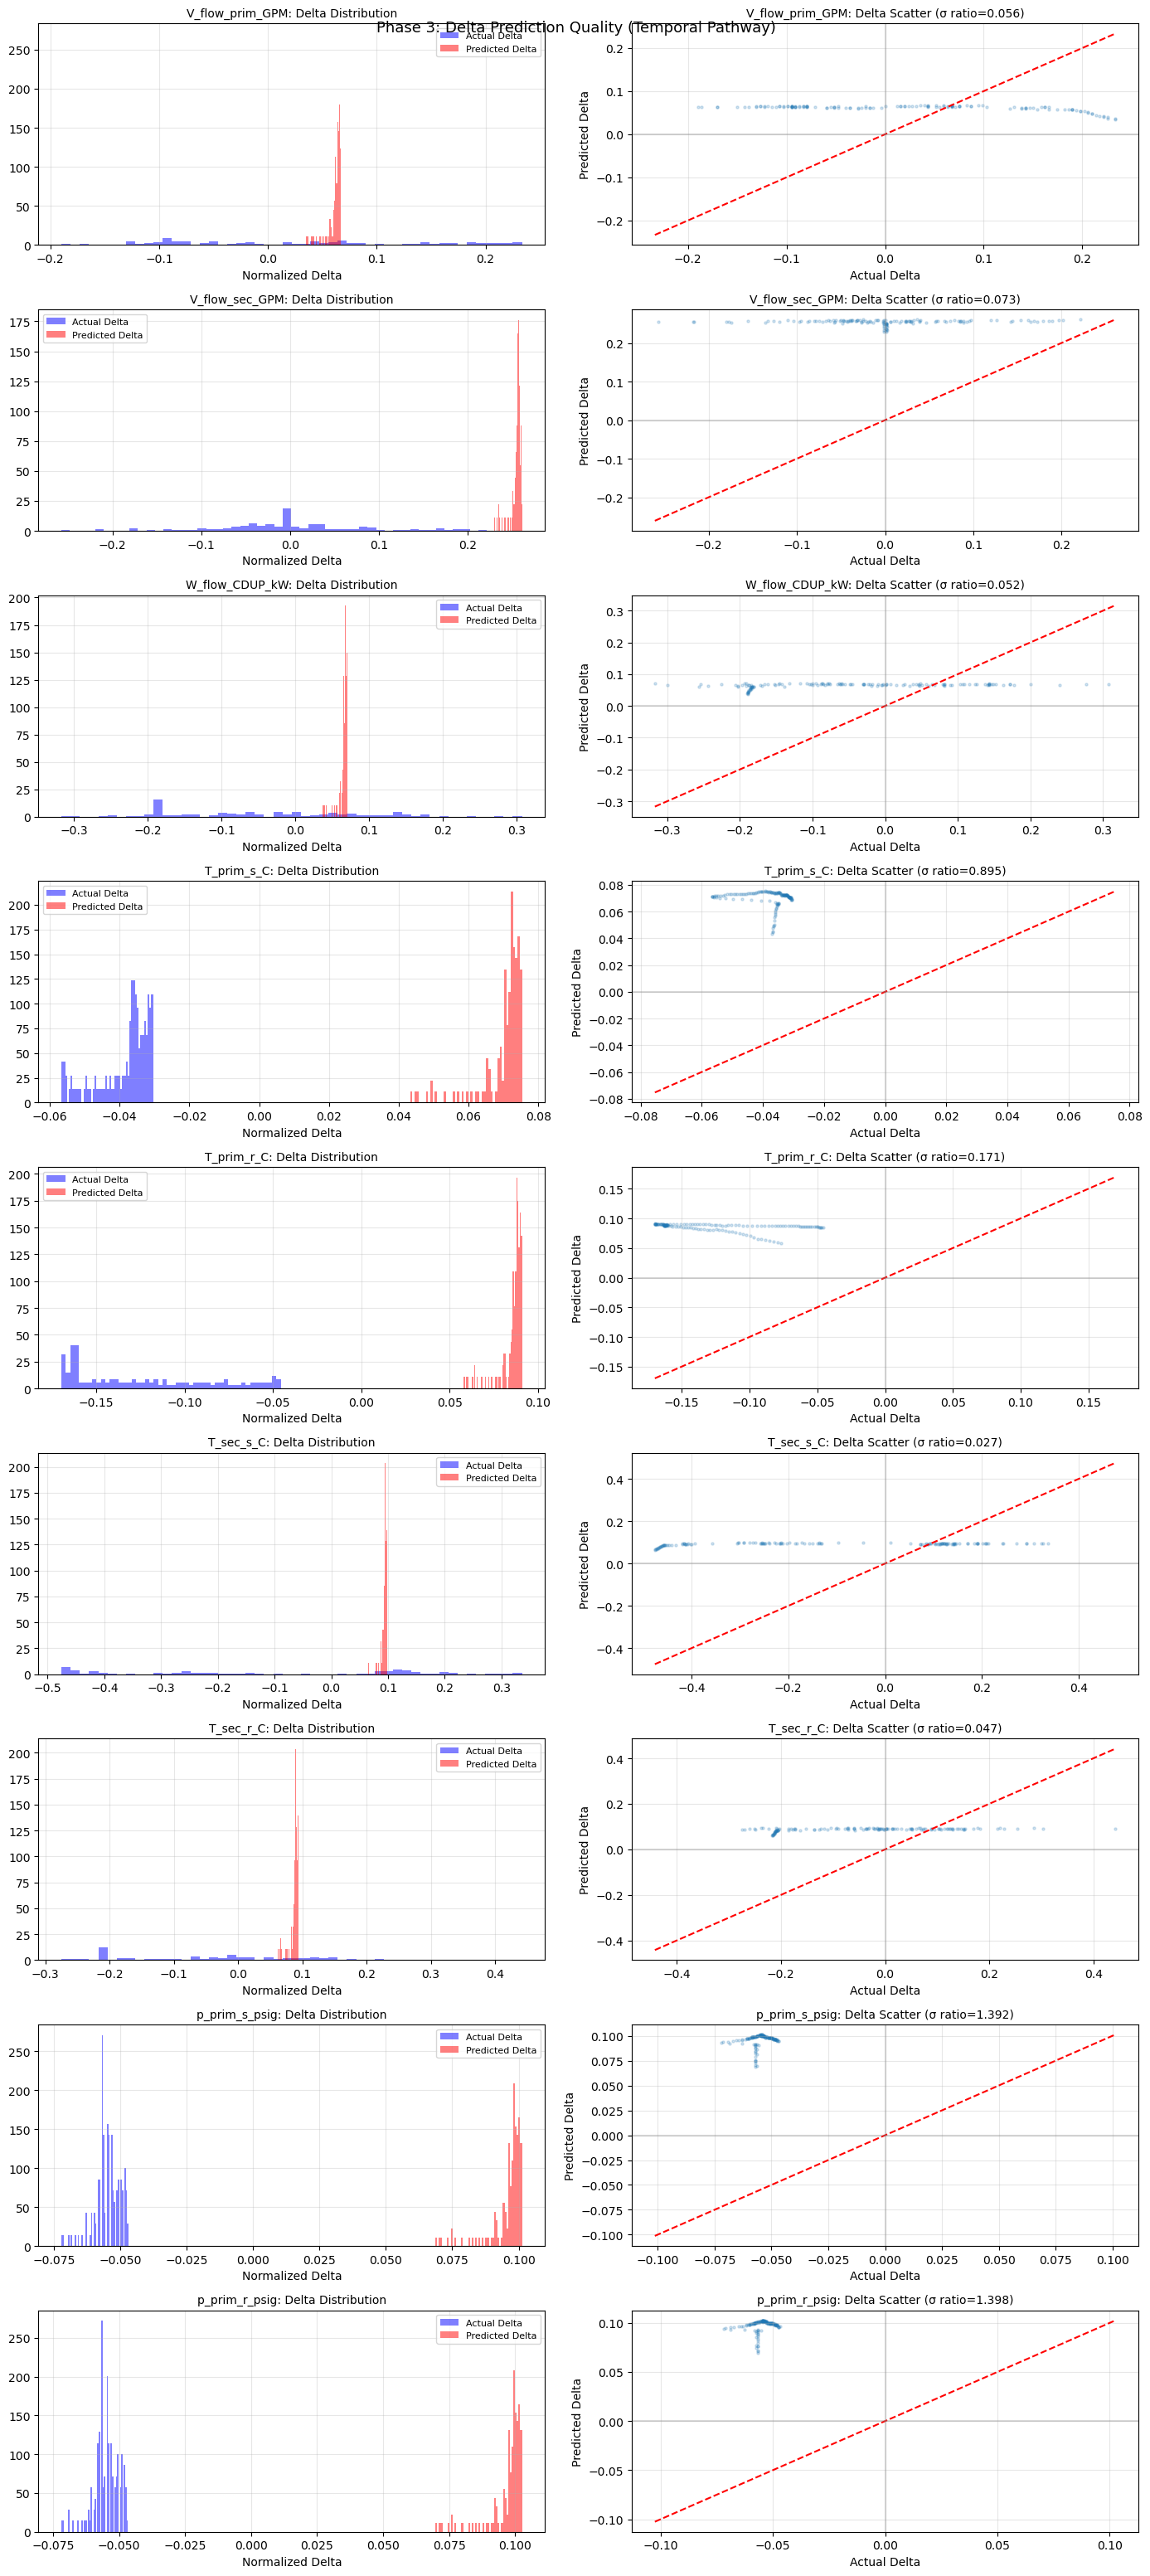

In [ ]:
#  Visualization 9 — Delta Prediction Quality (Temporal Pathway)

def plot_delta_quality(predictions_dict, column_info, config):
    """Visualize delta prediction quality for temporal outputs."""
    pred_norm = predictions_dict['pred_temporal_norm']
    target_norm = predictions_dict['target_temporal_norm']
    temporal_cols = column_info['temporal_cols']

    # Select one column per temporal output type
    type_examples = {}
    for t_idx, col in enumerate(temporal_cols):
        otype = column_info['col_to_type'].get(col)
        if otype not in type_examples:
            type_examples[otype] = t_idx

    n_types = len(type_examples)
    fig, axes = plt.subplots(n_types, 2, figsize=(14, 3.5 * n_types))
    if n_types == 1:
        axes = axes.reshape(1, -1)

    for row, (otype, t_idx) in enumerate(type_examples.items()):
        pred_d = pred_norm[:, 0, t_idx]
        true_d = target_norm[:, 0, t_idx]

        ax = axes[row, 0]
        ax.hist(true_d, bins=50, alpha=0.5, label='Actual Delta', density=True, color='blue')
        ax.hist(pred_d, bins=50, alpha=0.5, label='Predicted Delta', density=True, color='red')
        ax.set_title(f'{otype}: Delta Distribution', fontsize=10)
        ax.set_xlabel('Normalized Delta')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

        ax = axes[row, 1]
        n_plot = min(3000, len(pred_d))
        plot_idx = np.random.choice(len(pred_d), n_plot, replace=False)
        ax.scatter(true_d[plot_idx], pred_d[plot_idx], alpha=0.2, s=5)
        lim = max(np.abs(true_d).max(), np.abs(pred_d).max())
        ax.plot([-lim, lim], [-lim, lim], 'r--', linewidth=1.5)
        ax.axhline(0, color='gray', linestyle='-', alpha=0.3)
        ax.axvline(0, color='gray', linestyle='-', alpha=0.3)

        std_ratio = np.std(pred_d) / (np.std(true_d) + 1e-10)
        ax.set_title(f'{otype}: Delta Scatter (σ ratio={std_ratio:.3f})', fontsize=10)
        ax.set_xlabel('Actual Delta')
        ax.set_ylabel('Predicted Delta')
        ax.grid(True, alpha=0.3)

    plt.suptitle('Phase 3: Delta Prediction Quality (Temporal Pathway)', fontsize=13)
    plt.tight_layout()
    plt.savefig('phase_3_vis/delta_quality.png', dpi=150, bbox_inches='tight')
    plt.show()


plot_delta_quality(predictions_dict, column_info, config)

## Save Results

In [ ]:
#  Save Model, Metrics, and Training History

save_dir = Path('./saved_models/phase3_hybrid_deeponet_fixes')
save_dir.mkdir(parents=True, exist_ok=True)

checkpoint = {
    'model_state_dict': model.state_dict(),
    'config': {
        'DEEPONET_HIDDEN': config.DEEPONET_HIDDEN,
        'DEEPONET_N_BASIS': config.DEEPONET_N_BASIS,
        'ALGEBRAIC_HIDDEN': config.ALGEBRAIC_HIDDEN,
        'ALGEBRAIC_LAYERS': config.ALGEBRAIC_LAYERS,
        'DROPOUT': config.DROPOUT,
        'EMBEDDING_DIM': config.EMBEDDING_DIM,
        'DRIFT_CORRECTION_STRENGTH': config.DRIFT_CORRECTION_STRENGTH,
        'ALPHA_REG_WEIGHT': config.ALPHA_REG_WEIGHT,
        'HISTORY_STEPS': config.HISTORY_STEPS,
        'PREDICTION_STEPS': config.PREDICTION_STEPS,
        'SUBSAMPLE_FACTOR': config.SUBSAMPLE_FACTOR,
        'OUTPUT_HISTORY_STEPS': config.OUTPUT_HISTORY_STEPS,
        'USE_INPUT_WHITENING': config.USE_INPUT_WHITENING,
        'temporal_input_size': temporal_input_size,
        'temporal_output_size': temporal_output_size,
        'algebraic_output_size': algebraic_output_size,
        'num_cdus': len(config.CDU_IDS),
    },
    'training': {
        'epochs': n_epochs_trained,
        'best_val_loss': early_stopping.best_loss,
        'training_time_sec': train_time,
        'total_params': total_params,
        'temporal_params': temporal_params,
        'algebraic_params': algebraic_params,
    },
}
torch.save(checkpoint, save_dir / 'phase3_deeponet_fixes_best.pth')
print(f"Model saved to: {save_dir / 'phase3_deeponet_fixes_best.pth'}")

metrics_df.to_csv(save_dir / 'metrics.csv', index=False)
print(f"Metrics saved to: {save_dir / 'metrics.csv'}")

with open(save_dir / 'training_history.json', 'w') as f:
    json.dump({k: [float(v) for v in vals] for k, vals in history.items()}, f, indent=2)
print(f"Training history saved to: {save_dir / 'training_history.json'}")

# Save alpha weights
alpha_data = predictions_dict['alpha']
np.save(save_dir / 'alpha_weights.npy', alpha_data)
print(f"Alpha weights saved to: {save_dir / 'alpha_weights.npy'}")

Model saved to: saved_models/phase3_hybrid_deeponet_fixes/phase3_deeponet_fixes_best.pth
Metrics saved to: saved_models/phase3_hybrid_deeponet_fixes/metrics.csv
Training history saved to: saved_models/phase3_hybrid_deeponet_fixes/training_history.json
Alpha weights saved to: saved_models/phase3_hybrid_deeponet_fixes/alpha_weights.npy


In [ ]:
#  Final Summary

print("\n" + "=" * 70)
print("PHASE 3: HYBRID DEEPONET WITH FIXES — FINAL SUMMARY")
print("=" * 70)

print(f"\nArchitecture:")
print(f"  Temporal: LSTM Branch ({config.DEEPONET_HIDDEN}) + Fourier Trunk → {config.DEEPONET_N_BASIS} basis")
print(f"    CDU embedding:     {config.EMBEDDING_DIM}-dim (per-output conditioning)")
print(f"    Skip connection:   learnable α (sigmoid-bounded, regularized)")
print(f"    Drift correction:  learnable β (pulls toward operating mean)")
print(f"  Algebraic: CDU-conditioned MLP (Q_flow + CDU_emb → p_sec)")
print(f"    CDU embedding:     {config.EMBEDDING_DIM}-dim")
print(f"    CDU-specific heads: {config.NUM_CDUS}")
print(f"  Total parameters: {total_params:,} (temporal: {temporal_params:,}, algebraic: {algebraic_params:,})")
print(f"  Prediction mode:  delta + skip + drift (temporal), absolute (algebraic)")
print(f"  Input whitening:  PCA ({config.WHITENING_COMPONENTS:.0%} variance)")

print(f"\nTraining:")
print(f"  Loss:             Huber+VarMatch (temporal) + MSE (algebraic) + α reg (w={config.ALPHA_REG_WEIGHT})")
print(f"  Optimizer:        AdamW (lr={config.LEARNING_RATE}, wd={config.WEIGHT_DECAY})")
print(f"  Scheduler:        Cosine annealing (T₀=20, T_mult=2)")
print(f"  Epochs:           {n_epochs_trained} (patience {config.PATIENCE})")
print(f"  Training time:    {train_time:.0f}s")

print(f"\nData:")
print(f"  History:          {config.HISTORY_SECONDS}s ({config.HISTORY_STEPS} steps)")
print(f"  Output history:   {config.OUTPUT_HISTORY_STEPS} steps")
print(f"  Prediction:       {config.PREDICTION_SECONDS}s ({config.PREDICTION_STEPS} steps)")
print(f"  CDUs:             {config.NUM_CDUS}")
print(f"  Total outputs:    {len(metrics_df)}")
print(f"  Temporal:         {len(column_info['temporal_cols'])}")
print(f"  Algebraic:        {len(column_info['algebraic_cols'])}")

print(f"\nPerformance (Test Set):")
print(f"  Mean R²:            {metrics_df['R²'].mean():.4f}")
print(f"  Median R²:          {metrics_df['R²'].median():.4f}")
print(f"  Outputs R² > 0.8:   {(metrics_df['R²'] > 0.8).sum()}/{len(metrics_df)}")
print(f"  Outputs R² > 0.9:   {(metrics_df['R²'] > 0.9).sum()}/{len(metrics_df)}")
print(f"  Variance Ratio:     {metrics_df['Variance_Ratio'].mean():.4f}")
print(f"  Beats Persistence:  {metrics_df['Beats_Persistence'].sum()}/{len(metrics_df)}")

print(f"\nSkip Connection (α):")
alpha = predictions_dict['alpha']
print(f"  Mean α:             {alpha.mean():.3f}")
print(f"  α range:            [{alpha.min():.3f}, {alpha.max():.3f}]")
print(f"  α at step 0:        {alpha[0].mean():.3f}")
print(f"  α at step -1:       {alpha[-1].mean():.3f}")

print(f"\nPer-Category Performance:")
for cat in ['A (Primary loop)', 'B (Secondary temp)', 'C (Primary flow)',
            'D (Secondary pressure)', 'E (Constant)']:
    cat_df = metrics_df[metrics_df['Category'] == cat]
    if len(cat_df) == 0:
        continue
    r2_mean = cat_df['R²'].mean()
    status = 'Excellent' if r2_mean > 0.9 else ('Good' if r2_mean > 0.7 else ('Fair' if r2_mean > 0.3 else 'Poor'))
    print(f"  {cat}: Mean R²={r2_mean:.4f} ({status}, {len(cat_df)} outputs)")

print(f"\nInference:")
print(f"  Total time:       {inference_time:.2f}s")
print(f"  Per sample:       {inference_time/n_test_samples*1000:.2f} ms")


PHASE 3: HYBRID DEEPONET WITH FIXES — FINAL SUMMARY

Architecture:
  Temporal: LSTM Branch (64) + Fourier Trunk → 32 basis
    CDU embedding:     16-dim (per-output conditioning)
    Skip connection:   learnable α (sigmoid-bounded, regularized)
    Drift correction:  learnable β (pulls toward operating mean)
  Algebraic: CDU-conditioned MLP (Q_flow + CDU_emb → p_sec)
    CDU embedding:     16-dim
    CDU-specific heads: 257
  Total parameters: 786,951 (temporal: 743,861, algebraic: 43,090)
  Prediction mode:  delta + skip + drift (temporal), absolute (algebraic)
  Input whitening:  PCA (99% variance)

Training:
  Loss:             Huber+VarMatch (temporal) + MSE (algebraic) + α reg (w=0.01)
  Optimizer:        AdamW (lr=0.001, wd=0.0001)
  Scheduler:        Cosine annealing (T₀=20, T_mult=2)
  Epochs:           21 (patience 20)
  Training time:    710s

Data:
  History:          1200s (40 steps)
  Output history:   30 steps
  Prediction:       30s (1 steps)
  CDUs:             257
  T